# BUSN 20800 · Big Data — End-to-End Midterm Preparation

**Purpose.** If you work through this notebook **carefully, from top to bottom**, you will be prepared for every category of question on the midterm.

## What's in here

1. **Math foundations** — just enough probability / likelihood / gradients to do the derivations.
2. **Linear regression** — the model, MLE=OLS, the four coefficient-interpretation cases, categorical encoding, interactions, omitted-variable bias.
3. **Logistic regression and GLMs** — the Bernoulli likelihood, the log-odds interpretation, full derivations of the logistic and probit score functions, gradient descent, multinomial (softmax).
4. **Regularization** — lasso, ridge, the full Bayesian MAP derivations, standardization, shrinkage bias.
5. **Model selection** — K-fold CV, AIC, BIC, forward stepwise, the 1-SE rule, `TimeSeriesSplit`, why AIC/BIC fail on non-iid data.
6. **Classification evaluation** — the confusion matrix, all six rates, ROC curves built by hand, AUC, decision-theoretic thresholds from cost / profit matrices.
7. **KNN** — the rule, Euclidean vs Hamming, bias–variance in $K$, feature scaling, non-linear boundaries.
8. **Synthesis** — how to choose a method; pros / cons; parametric vs non-parametric; supervised / unsupervised / reinforcement paradigms; visualization grammar.
9. **A full simulated midterm** with detailed answer keys.
10. **A dense final review sheet** — the same content as `CHEATSHEET.ipynb`.

Each section follows the same rhythm:

> **Intuition → formal statement → worked derivation → worked example → exercises → solutions.**

Exercises have their solutions in the cell *immediately below* them. Try every one before peeking.

## How to use

- **First pass (3–4 hours):** read every cell, work every example, attempt every exercise, check against the solution. Mark cells you found hard.
- **Second pass (1–2 hours):** re-read only the intuitions and do the simulated exam (§10) under timed conditions.
- **Night before:** transcribe §11 (the dense review sheet) onto paper — that is what you bring to the exam.

The exam itself is **pen-and-paper** with no code allowed. Every code snippet in this notebook is purely for **building intuition** and is labelled as such.


## §0.1 Exam logistics (from the review deck and practice PDF)

- Mix of (a) multiple-choice, (b) concept checks, (c) short-answer derivations.
- You will be asked to **derive** likelihoods, score functions, and MAP estimators; **interpret** regression output; **compute** rates from a confusion matrix; **construct** an ROC point-by-point; and **derive** optimal decision thresholds from business payoff matrices.
- You will **not** be asked to write Python, recall sklearn argument names, or implement algorithms in code.
- The review deck is 17 slides; the practice PDF has 7 MC + 5 concept-check + 2 short-answer. Our simulated exam in §10 matches this structure.


## §0.2 Notation used throughout

| symbol | meaning |
|---|---|
| $x_i \in \mathbb R^p$ | feature vector for obs $i$ (row of design matrix $X$) |
| $y_i$ | outcome for obs $i$ (continuous, binary, or categorical) |
| $\beta \in \mathbb R^p$ | parameter vector (intercept often absorbed into $x_i$ by prepending a 1) |
| $\hat y_i$ | fitted value |
| $\hat p_i$ | predicted probability $P(Y_i=1\mid x_i)$ |
| $\ell(\beta)$ | log-likelihood |
| $L(\beta)$ | likelihood |
| $\text{Dev}(\beta)=-2\ell(\beta)$ | deviance |
| $\sigma(z) = 1/(1+e^{-z})$ | sigmoid / logistic CDF |
| $\Phi(z), \phi(z)$ | standard-normal CDF and pdf |
| $n_P, n_N$ | # positives / negatives in the test set |
| $t$ | classification threshold |
| $\lambda$ | regularization strength |
| $\bar y = n^{-1}\sum y_i$ | sample mean |


---

# Chapter 1 — Mathematical Foundations

Before we can fit any model, we need three mathematical ideas:
1. **Likelihood** — the probability of observing the data as a function of the parameters.
2. **Bayes' rule** — how prior beliefs combine with data to give posterior beliefs.
3. **Deviance** — a rescaling of the log-likelihood that turns maximization into minimization.

Everything in this course is built on top of these three ideas.


## §1.1 Probability quick refresher

A **random variable** $Y$ has a density (or mass) $p(y)$. The expectation is $E[Y] = \int y\,p(y)\,dy$ (or sum).

Three random variables we will use repeatedly:

| name | density / mass | mean | variance |
|---|---|---|---|
| **Normal** $\mathcal N(\mu,\sigma^2)$ | $\displaystyle\frac{1}{\sigma\sqrt{2\pi}}\exp\!\left(-\frac{(y-\mu)^2}{2\sigma^2}\right)$ | $\mu$ | $\sigma^2$ |
| **Bernoulli** $(p)$ | $p^y(1-p)^{1-y},\ y\in\{0,1\}$ | $p$ | $p(1-p)$ |
| **Laplace** $(0, b)$ | $\displaystyle\frac{1}{2b}\exp(-\lvert y\rvert/b)$ | $0$ | $2b^2$ |

**Independence.** Random variables $Y_1,\ldots,Y_n$ are *independent* if
$$p(y_1,\ldots,y_n) = \prod_{i=1}^n p(y_i).$$
*iid* means independent and identically distributed.

**Why independence matters.** When observations are iid, likelihoods *factor* into a product. Taking $\log$ converts the product into a **sum**, which is what lets us actually compute derivatives.


## §1.2 The likelihood

Given a statistical model $p(y\mid x, \beta)$ and a dataset $(x_i, y_i)_{i=1}^n$, the **likelihood** is the probability of observing the data, viewed as a **function of the parameters** $\beta$:
$$L(\beta) \;=\; p(\mathbf y \mid X, \beta) \;=\; \prod_{i=1}^n p(y_i \mid x_i, \beta).$$

The **log-likelihood** is
$$\ell(\beta) \;=\; \log L(\beta) \;=\; \sum_{i=1}^n \log p(y_i \mid x_i, \beta).$$

**Why we always work with $\ell$, not $L$.**
- Log turns products into sums — easier derivatives.
- Log squashes astronomically small probabilities into numerically friendly numbers.
- $\log$ is strictly increasing, so $\arg\max_\beta L(\beta) = \arg\max_\beta \ell(\beta)$.

The **maximum likelihood estimator** (MLE) is
$$\hat\beta_{\text{MLE}} \;=\; \arg\max_\beta \ell(\beta).$$


### §1.2.1 The three operations you'll do over and over

Given a likelihood, you'll perform these three moves almost every derivation:

1. **Take $\log$.** Converts $\prod$ to $\sum$.
2. **Drop constants** that don't depend on $\beta$. Preserves argmax.
3. **Multiply by $-1$ or a positive constant.** Flips $\arg\max$ to $\arg\min$ (if you multiply by a negative number), or just rescales the objective.

Example. For a Gaussian with known variance,
$$\log p(y_i\mid x_i,\beta) = -\tfrac12\log(2\pi\sigma^2) - \frac{(y_i - x_i'\beta)^2}{2\sigma^2}.$$
Summing, dropping the $-\tfrac n2\log(2\pi\sigma^2)$ constant and the $1/(2\sigma^2)$ positive multiplier:
$$\arg\max_\beta \ell(\beta) \;=\; \arg\min_\beta \sum_i (y_i - x_i'\beta)^2 \;=\; \arg\min_\beta \text{RSS}(\beta).$$

So **MLE with Gaussian errors = OLS**. You will see this derivation four times in this course.


## §1.3 Bayes' rule

If $\theta$ is an unknown parameter with prior density $p(\theta)$, and we observe data $d$ with likelihood $p(d\mid\theta)$, then Bayes' rule says:
$$p(\theta \mid d) \;=\; \frac{p(d \mid \theta)\,p(\theta)}{p(d)} \;\propto\; p(d\mid\theta)\,p(\theta).$$

The denominator $p(d) = \int p(d\mid\theta)\,p(\theta)\,d\theta$ is a constant in $\theta$ — it's called the **evidence** or **marginal likelihood**. When we only want the **argmax** (the MAP — maximum a posteriori estimate), the evidence drops out:
$$\hat\theta_{\text{MAP}} \;=\; \arg\max_\theta\,p(d\mid\theta)\,p(\theta) \;=\; \arg\max_\theta\big[\log L(\theta) + \log p(\theta)\big].$$

**Exam move.** \"MAP = MLE + log prior.\" The prior acts like an **extra term in the log-likelihood**. Chapter 5 will use this to show **lasso = MAP under a Laplace prior** and **ridge = MAP under a Gaussian prior**.

### iid form
If the data consist of iid observations $(y_1, \ldots, y_n)$, then
$$p(y_1, \ldots, y_n \mid \beta) = \prod_{i=1}^n p(y_i \mid \beta).$$


## §1.4 Deviance

The **deviance** is just a rescaling of the negative log-likelihood:
$$\text{Dev}(\beta) \;=\; -2\,\ell(\beta).$$

**Why multiply by $-2$?** Historical convention from Wilks' theorem: for nested models, twice the log-likelihood ratio is asymptotically $\chi^2$-distributed. For this course, just remember:

$$\arg\max_\beta L(\beta) \;=\; \arg\max_\beta \ell(\beta) \;=\; \arg\min_\beta \text{Dev}(\beta).$$

**For the Bernoulli (binomial) model:**
$$\text{Dev}(\beta) = -2\sum_i \big[ y_i \log p_i + (1 - y_i) \log(1 - p_i)\big].$$

**For the Gaussian model:**
$$\text{Dev}(\beta) = n\log(2\pi\sigma^2) + \frac{1}{\sigma^2}\sum_i(y_i - x_i'\beta)^2.$$
(Up to a constant that doesn't depend on $\beta$, this is just RSS$/\sigma^2$.)


## §1.5 Gradients and gradient descent (30-second refresher)

The **gradient** $\nabla f(\beta)$ is the vector of partial derivatives of $f$ with respect to each component of $\beta$. At the minimum, $\nabla f = \mathbf 0$.

**Gradient descent** iteratively moves in the direction of steepest *decrease*:
$$\beta_{t+1} = \beta_t - \eta\,\nabla f(\beta_t),$$
where $\eta > 0$ is the **learning rate**. Stop when $\|\beta_{t+1} - \beta_t\|$ is below a **tolerance**.

**Chain rule** is your main tool. If $f(\beta) = g(h(\beta))$ then
$$\frac{df}{d\beta} = g'(h(\beta))\cdot h'(\beta).$$
For composite scalar-valued functions of vector arguments, the chain rule gives a vector gradient (inner derivative times outer derivative).

The two logistic-regression score derivations you must know both use the chain rule twice.


## §1.6 Exercises — chapter 1

> **E1.1.** Write down the Bernoulli log-likelihood for $n$ iid observations with $p_i$ depending on $\beta$.
>
> **E1.2.** Show that if $g$ is strictly increasing, $\arg\max_\beta f(\beta) = \arg\max_\beta g(f(\beta))$.
>
> **E1.3.** A dataset has $y_i \in \{0,1\}$ with $\hat p_i$ given, and deviance $\text{Dev} = 138$. What is $\ell$?
>
> **E1.4.** True / false: \"If the prior is uniform, the MAP equals the MLE.\" Justify.
>
> **E1.5.** (*Computational.*) For data $(x_i,y_i)$ with $x_i\in\mathbb R$ and Gaussian errors of **known** variance $\sigma^2$, what is $\frac{\partial \ell}{\partial \beta_1}$ in terms of residuals $r_i = y_i - x_i'\beta$?


### Solutions — chapter 1

**S1.1.** $\ell(\beta) = \sum_{i=1}^n\big[y_i \log p_i(\beta) + (1-y_i)\log(1-p_i(\beta))\big].$

**S1.2.** Suppose $\beta^\star = \arg\max f(\beta)$. For any $\beta$, $f(\beta) \le f(\beta^\star)$. Applying $g$ (strictly increasing): $g(f(\beta)) \le g(f(\beta^\star))$. Therefore $\beta^\star$ is also an argmax of $g\circ f$. $\log$ is strictly increasing, so this justifies \"always take logs.\"

**S1.3.** $\text{Dev} = -2\ell \Rightarrow \ell = -\text{Dev}/2 = -69.$

**S1.4.** True. If $p(\beta)$ is a constant $c$ (uniform), then $\log p(\beta) = \log c$ doesn't depend on $\beta$, so $\arg\max[\ell + \log p] = \arg\max \ell$. MAP = MLE.

**S1.5.** $\frac{\partial \ell}{\partial \beta_1} = \frac{1}{\sigma^2}\sum_i r_i x_{i1}$. Chain rule: $\frac{\partial}{\partial \beta_1}(y_i - x_i'\beta)^2 = -2 r_i x_{i1}$; summing and applying the $-1/(2\sigma^2)$ coefficient reverses the sign.


---

# Chapter 2 — Linear Regression · Part I (Model & Fit)

## §2.1 The model

$$y_i = \beta_0 + \beta_1 x_{i1} + \cdots + \beta_p x_{ip} + \varepsilon_i,\qquad \varepsilon_i \overset{iid}{\sim} \mathcal N(0,\sigma^2).$$

Stacking observations: $\mathbf y = X\beta + \boldsymbol\varepsilon$ with $X$ an $n\times(p+1)$ design matrix (first column all 1s for the intercept) and $\boldsymbol\varepsilon \sim \mathcal N(\mathbf 0, \sigma^2 I_n)$.

**Interpretation.** $\beta_j$ is the *expected change in $y$ per unit change in $x_j$, holding all other features fixed.*

**Assumptions** (roughly in order of importance):
1. **Linearity in parameters** (*essential*) — the right-hand side is linear in $\beta$. $x$ can enter through non-linear transforms (logs, squares, indicators) and the model is still \"linear\".
2. **No perfect collinearity** — no feature is a linear combination of the others (else $X'X$ is not invertible).
3. **Exogeneity** — $E[\varepsilon_i \mid X] = 0$. Needed for unbiased estimation. *Violated whenever there's omitted-variable bias* (see §3.4).
4. **Homoskedasticity** — $\text{Var}(\varepsilon_i \mid X) = \sigma^2$. Needed for usual SE formulas; not needed for coefficient unbiasedness.
5. **Normality** — $\varepsilon_i \sim \mathcal N$. Needed for finite-sample inference (t-tests). Large-$n$ inference uses the CLT instead.

This course focuses on **prediction** — points 1–3 matter most.


## §2.2 Derivation: MLE = OLS (memorize)

Under the model in §2.1, $y_i \mid x_i,\beta \sim \mathcal N(x_i'\beta, \sigma^2)$.

**Step 1 — density.**
$$p(y_i\mid x_i,\beta) = \frac{1}{\sigma\sqrt{2\pi}}\exp\!\left(-\frac{(y_i - x_i'\beta)^2}{2\sigma^2}\right).$$

**Step 2 — likelihood (iid product).**
$$L(\beta) = \prod_i p(y_i\mid x_i,\beta) = (2\pi\sigma^2)^{-n/2}\exp\!\left(-\frac{1}{2\sigma^2}\sum_i (y_i - x_i'\beta)^2\right).$$

**Step 3 — log-likelihood.**
$$\ell(\beta) = -\tfrac n 2 \log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\underbrace{\sum_i (y_i - x_i'\beta)^2}_{\text{RSS}(\beta)}.$$

**Step 4 — drop the constants in $\beta$.**
$$\arg\max_\beta \ell(\beta) = \arg\min_\beta \text{RSS}(\beta).$$

So the MLE under Gaussian errors **is OLS**. $\blacksquare$

### The closed-form solution (good to know, not tested)
Setting $\nabla_\beta \text{RSS}(\beta) = -2 X'(\mathbf y - X\beta) = \mathbf 0$ gives the **normal equations** $X'X\hat\beta = X'\mathbf y$, so
$$\hat\beta = (X'X)^{-1}X'\mathbf y.$$


## §2.3 Evaluating a continuous-outcome model

| quantity | formula | what it measures |
|---|---|---|
| RSS | $\sum(\hat y_i - y_i)^2$ | total squared error |
| TSS | $\sum(y_i - \bar y)^2$ | variance of $y$ (× $n$) |
| MSE | RSS / $n$ | average squared error |
| $R^2$ | $1 - \text{RSS}/\text{TSS}$ | fraction of variance explained |
| Adjusted $R^2$ | $1 - \frac{\text{RSS}/(n-p-1)}{\text{TSS}/(n-1)}$ | penalizes extra features (rarely tested in this course) |

- $R^2 \in [0,1]$ *on training data* (adding features never decreases it).
- $R^2$ *on test data* can be **negative** — the model can be worse than predicting $\bar y$.
- The **overfitting signature** is a large gap: train $R^2$ much higher than test $R^2$.

### Train / test split
Set aside a random fraction (commonly 20%) of the data as a **test set** before fitting. Compute training metrics on the fit set and **test** metrics on the held-out set. Never touch the test set while tuning — any look at it \"burns\" it.


## §2.4 Worked example — hand OLS on 3 points

Data: $(x,y) = (1,2),\ (2,4),\ (3,5)$.

With intercept: $X = \begin{pmatrix} 1 & 1 \\ 1 & 2 \\ 1 & 3\end{pmatrix},\ \mathbf y = (2,4,5)'$.

$X'X = \begin{pmatrix} 3 & 6 \\ 6 & 14 \end{pmatrix},\quad X'\mathbf y = \begin{pmatrix} 11 \\ 25 \end{pmatrix}.$

$\det(X'X) = 3 \cdot 14 - 6 \cdot 6 = 42 - 36 = 6$.
$(X'X)^{-1} = \frac{1}{6}\begin{pmatrix} 14 & -6 \\ -6 & 3 \end{pmatrix}.$

$\hat\beta = (X'X)^{-1} X'\mathbf y = \frac{1}{6}\begin{pmatrix} 14\cdot 11 + (-6)\cdot 25 \\ -6\cdot 11 + 3\cdot 25\end{pmatrix} = \frac{1}{6}\begin{pmatrix} 4 \\ 9 \end{pmatrix} = \begin{pmatrix} 0.667 \\ 1.5 \end{pmatrix}.$

So $\hat y = 0.67 + 1.5 x$. Fitted values: $2.17, 3.67, 5.17$. Residuals: $-0.17, 0.33, -0.17$.

$\text{RSS} = 0.17^2 + 0.33^2 + 0.17^2 \approx 0.167$.

$\bar y = 11/3 \approx 3.67$. $\text{TSS} = (2-3.67)^2 + (4-3.67)^2 + (5-3.67)^2 \approx 2.79 + 0.11 + 1.78 = 4.67$.

$R^2 = 1 - 0.167/4.67 \approx 0.964.$


## §2.5 Exercises — chapter 2

> **E2.1.** $n = 100$, RSS = 40, TSS = 200. Compute $R^2$ and MSE.
>
> **E2.2.** A model has training RSS = 10 and test RSS = 100, with equal-size train/test sets. Diagnose.
>
> **E2.3.** Using the three-point data from §2.4, re-do the derivation without the intercept (force $\beta_0 = 0$). Report $\hat\beta_1$ and the new $R^2$.
>
> **E2.4.** Show that the first normal equation $\mathbf 1'(\mathbf y - X\hat\beta) = 0$ implies the **residuals sum to zero** whenever an intercept is included.
>
> **E2.5.** *(Short.)* What does $R^2 < 0$ on a test set *mean*?


### Solutions — chapter 2

**S2.1.** $R^2 = 1 - 40/200 = 0.80.$ MSE = 40/100 = 0.40.

**S2.2.** Classic **overfitting**: huge gap between training and test RSS. The model memorized training noise.

**S2.3.** Without intercept, $X = (1,2,3)'$ and $X'X = 1^2 + 2^2 + 3^2 = 14$; $X'\mathbf y = 1\cdot 2 + 2\cdot 4 + 3\cdot 5 = 25$. So $\hat\beta_1 = 25/14 \approx 1.786$. Fitted: 1.79, 3.57, 5.36. Residuals: 0.21, 0.43, −0.36. $\text{RSS} \approx 0.33$. $R^2 = 1 - 0.33/4.67 \approx 0.93$ (lower than with intercept, as expected).

**S2.4.** The first normal equation is obtained by differentiating RSS w.r.t. $\beta_0$ and setting to zero: $-2\sum_i(y_i - \hat y_i) = 0$, i.e., $\sum_i \hat\varepsilon_i = 0$. Residuals sum to zero. (No intercept = residuals need not sum to zero.)

**S2.5.** Negative test $R^2$ means the fitted model predicts *worse* on the test set than simply predicting the training-sample mean $\bar y$. A red flag for overfitting or a distributional shift between train and test.


---

# Chapter 3 — Linear Regression · Part II (Interpreting output)

The midterm will place a regression table in front of you and ask what the numbers mean. This chapter is the grammar of reading that table.


## §3.1 The four log / level cases

For a single covariate $x_1$ with coefficient $\beta_1$, assuming other variables are held constant:

| model | form | interpretation of $\beta_1$ |
|---|---|---|
| level–level | $y = \beta_0 + \beta_1 x_1 + \cdots$ | a 1-unit increase in $x_1$ is associated with a $\beta_1$-unit change in $y$ |
| log–level (semi-elasticity) | $\log y = \beta_0 + \beta_1 x_1 + \cdots$ | a 1-unit increase in $x_1$ is associated with a $\approx 100\beta_1\%$ change in $y$ |
| level–log | $y = \beta_0 + \beta_1 \log x_1 + \cdots$ | a 1% increase in $x_1$ is associated with a $\beta_1/100$-unit change in $y$ |
| log–log (elasticity) | $\log y = \beta_0 + \beta_1 \log x_1 + \cdots$ | a 1% increase in $x_1$ is associated with a $\beta_1\%$ change in $y$ |

**Mnemonic.** *Log on a side → percent on that side.*

### Why the 100 factor?
A tiny change in $\log y$ is approximately a relative change in $y$:
$$d(\log y) = \frac{dy}{y} \approx \frac{\Delta y}{y}.$$
So $\Delta(\log y) \approx 0.01$ corresponds to a 1% change in $y$. That's where the \"100\" shows up when you translate to percentage terms.


## §3.2 Worked examples — each case

**Level–level.** `price ~ size`, $\hat\beta_{\text{size}} = 1.50$ (dollars per sqft). A 100 sqft larger house is $\$150$ more expensive on average.

**Log–level.** `log(wage) ~ education`, $\hat\beta_{\text{edu}} = 0.08$. One more year of education is associated with a $\approx 8\%$ higher wage.

**Level–log.** `lifespan ~ log(GDP)`, $\hat\beta = 6$. A 1% increase in GDP is associated with $6/100 = 0.06$-year (≈ 22 days) longer lifespan.

**Log–log.** `log(demand) ~ log(price)`, $\hat\beta = -1.6$. The price elasticity of demand is −1.6: a 1% price increase is associated with 1.6% lower demand. *Elastic* (|elasticity| > 1).


## §3.3 Categorical features and the reference level

When a covariate takes a finite set of values (levels), we encode it with **dummy variables**: one indicator per level, minus one (the *reference level*) to avoid perfect collinearity with the intercept.

`pd.get_dummies(df, drop_first=True)` drops the first alphabetically-sorted level.

**Example.** `brand ∈ {Dominick's, Minute Maid, Tropicana}`, reference = Dominick's. After encoding,
$$\hat y = \hat\beta_0 + \hat\beta_{\text{MM}}\,\mathbb 1_{\text{MM}} + \hat\beta_{\text{Tro}}\,\mathbb 1_{\text{Tro}}.$$

- For a Dominick's observation (both indicators 0), $\hat y = \hat\beta_0$.
- For Minute Maid, $\hat y = \hat\beta_0 + \hat\beta_{\text{MM}}$.
- So $\hat\beta_{\text{MM}}$ is the difference **between Minute Maid and Dominick's**.

**Reference-level trap.** If the question asks \"compare Minute Maid with Tropicana,\" you need $\hat\beta_{\text{MM}} - \hat\beta_{\text{Tro}}$ — the coefficients by themselves aren't the cross-comparison.

### Ordered categoricals (age, income)
Treating an ordered category like `{under20k, 20-60k, 60-100k, 100-200k, 200k+}` with `get_dummies` throws away the ordering. For a linear model, it is often better to:
- Encode with an **integer ordinal code** (0, 1, 2, 3, 4) — imposes linear effect.
- Use **polynomial contrasts** or **monotone splines** if you expect non-linear effects.

This was Assignment 4 Q4b's concern.


## §3.4 Interactions — simple slopes

`y ~ x1 * x2` with two continuous variables expands to
$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_{12} x_1 x_2 + \varepsilon.$$

The slope of $y$ on $x_1$ **depends on $x_2$**:
$$\frac{\partial E[y]}{\partial x_1} = \beta_1 + \beta_{12}\,x_2.$$

- At $x_2 = 0$: slope is just $\beta_1$.
- At $x_2 = c$: slope is $\beta_1 + \beta_{12}\,c$.

**Always write out both (or all) \"simple slopes.\"**

### Worked example — Assignment 2 Q3
`int_rate ~ loan_amnt * term`:
- $\hat\beta_0 = 0.1278$, $\hat\beta_{\text{loan}} = -0.00004$
- $\hat\beta_{60} = 0.0271$ (term has 60 as non-reference)
- $\hat\beta_{\text{loan:60}} = 0.00103$

For a **36-month loan**: slope on loan size is $-0.00004$ (essentially zero).
For a **60-month loan**: slope on loan size is $-0.00004 + 0.00103 = 0.00099$.

So loan-size effect only appears on long-term loans. And the *intercept* shifts by $0.0271$ for 60-month loans — they're ~2.7 percentage-points more expensive before any loan-size effect.

### Categorical × categorical
`y ~ A * B` with each categorical gives one dummy per level (minus reference) plus one dummy per cross-level (minus those with a reference component). Interpret each in terms of differences **from the reference level of both variables**.


## §3.5 Omitted-variable bias (OVB)

**The setup.** Suppose the true model is
$$y = \beta_1 x_1 + \beta_2 x_2 + \varepsilon,$$
with $E[\varepsilon\mid x_1, x_2] = 0$. But we fit the **short regression** $y \sim x_1$ only, omitting $x_2$.

**Result.** The OLS estimate from the short regression has expected value
$$E[\hat\beta_1^{\text{short}}] \;=\; \beta_1 + \beta_2\cdot\frac{\text{Cov}(x_1, x_2)}{\text{Var}(x_1)}.$$

The bias is
$$\text{bias} = E[\hat\beta_1^{\text{short}}] - \beta_1 = \beta_2\cdot\frac{\text{Cov}(x_1, x_2)}{\text{Var}(x_1)}.$$

**Sign rule.**
$$\boxed{\;\text{sign(bias)} \;=\; \text{sign}(\beta_2)\cdot\text{sign}(\text{corr}(x_1, x_2)).\;}$$

### Four cases

| $\beta_2$ | corr$(x_1, x_2)$ | bias in $\hat\beta_1^{\text{short}}$ |
|---|---|---|
| + | + | + (overestimate) |
| + | − | − (underestimate) |
| − | + | − (underestimate) |
| − | − | + (overestimate) |

### Assignment 2 Q4 example
Omitting **log(income)** (which has $\beta_2 < 0$) from a regression of `int_rate` on `loan_amnt`. `loan_amnt` is positively correlated with `log(income)` ($+$). Bias sign $= (-)\cdot(+) = -$, so the short-regression coefficient is biased *below* the true value. Adding income reveals a **larger** coefficient — which is exactly what we observed (0.00114 → 0.00148).


## §3.6 Prediction vs causal interpretation

A coefficient is a **causal** effect only if every variable correlated with both the treatment $x_1$ and the outcome $y$ is controlled for. In observational data, this is nearly impossible to satisfy — you can never be sure you've controlled for *everything*.

**Implication.** $\hat\beta$ tells you the **predictive** association between $x_1$ and $y$ holding the *other included* regressors fixed. Not the causal effect unless you can argue why no unobserved confounders exist.

**Rule of thumb for the exam.** Treat every regression coefficient as *predictive* unless the question explicitly says otherwise.


## §3.7 Exercises — chapter 3

> **E3.1.** Interpret $\hat\beta = -2.5$ in `log(demand) ~ log(price)`.
>
> **E3.2.** `wage ~ education` with `{HS, College, Grad}`, reference = HS. $\hat\beta_{\text{College}} = 12$, $\hat\beta_{\text{Grad}} = 22$. (a) Predicted wage of an HS worker? (b) Gap between Grad and College?
>
> **E3.3.** `yield ~ fert * irrig` gives $\hat\beta_0 = 10$, $\hat\beta_{\text{fert}} = 0.5$, $\hat\beta_{\text{irrig}} = 2$, $\hat\beta_{\text{fert:irrig}} = 1.3$. What is the expected yield (a) with fert=10, irrig=0 (b) fert=10, irrig=1?
>
> **E3.4.** True model $y = 2 x_1 + 3 x_2 + \varepsilon$ with corr$(x_1, x_2) = -0.4$. Regress $y\sim x_1$ only. Is $\hat\beta_1$ biased above or below 2?
>
> **E3.5.** A researcher observes that $\hat\beta_{\text{smoking}}$ in a cancer regression is positive and statistically significant. Can they conclude smoking causes cancer?


### Solutions — chapter 3

**S3.1.** Price elasticity = −2.5. A 1% price increase ⇒ 2.5% lower demand. Very elastic.

**S3.2.** (a) $\hat\beta_0$ — need a numerical intercept. Assume intercept = 30 (or whatever the table gives). A HS worker earns \$30. (b) Grad–College gap = $22 - 12 = 10$.

**S3.3.** (a) With irrig=0: yield = $10 + 0.5\cdot 10 + 2\cdot 0 + 1.3\cdot 10\cdot 0 = 15$. (b) With irrig=1: $10 + 0.5\cdot 10 + 2\cdot 1 + 1.3\cdot 10 = 10 + 5 + 2 + 13 = 30$.

**S3.4.** Sign(bias) = sign($\beta_2$) · sign(corr) = $(+)(-) = (-)$. Biased **below** 2.

**S3.5.** No — at most they can say smoking is *predictively* associated with cancer in this sample. Causal claims require ruling out confounding (genetics, socioeconomic status, other lifestyle factors) and reverse causality.


---

# Chapter 4 — Logistic Regression & Generalized Linear Models

## §4.1 Why not linear for binary outcomes?

Suppose $Y_i \in \{0, 1\}$ and we just fit $y \sim X\beta$ with OLS. Two problems:
1. $\hat y_i$ can be **outside $[0,1]$** — not a valid probability.
2. The residual variance $p_i(1-p_i)$ depends on $p_i$ — so OLS standard errors are wrong (heteroskedasticity is built in).

**The fix: a link function.** Model the probability as
$$P(Y_i = 1 \mid x_i) = f(x_i'\beta),$$
where $f: \mathbb R \to (0, 1)$ is an increasing \"squashing\" function. This keeps predictions in $(0, 1)$ automatically.

Two popular choices: **sigmoid (logit)** and **probit**.


## §4.2 The sigmoid (logit) link

$$\sigma(z) = \frac{1}{1+e^{-z}} = \frac{e^z}{1+e^z}.$$

**Properties.**
- $\sigma: \mathbb R \to (0, 1)$, strictly increasing.
- $\sigma(0) = 0.5$.
- $\sigma(z) + \sigma(-z) = 1$.
- **Derivative identity** (used constantly): $\sigma'(z) = \sigma(z)(1-\sigma(z))$.

### Logit = inverse of sigmoid
If $p = \sigma(z)$ then $z = \log\frac{p}{1-p}$. The **log-odds** (also called *logit*) is exactly the linear predictor:
$$\log\frac{p_i}{1-p_i} = x_i'\beta.$$

So **one unit increase in $x_j$ ⇒ log-odds goes up by $\beta_j$ ⇒ odds multiply by $e^{\beta_j}$**.

**NOT** \"probability changes by $\beta_j$.\" The probability change is nonlinear, depending on where you start on the sigmoid.


## §4.3 The Bernoulli likelihood and logistic deviance

Each observation is $Y_i \mid x_i \sim \text{Bernoulli}(p_i)$ with $p_i = \sigma(x_i'\beta)$. The density is
$$p(y_i\mid x_i,\beta) = p_i^{y_i}(1-p_i)^{1-y_i}.$$

**Log-likelihood:**
$$\ell(\beta) = \sum_{i=1}^n \big[ y_i \log p_i + (1-y_i)\log(1-p_i)\big].$$

**Binomial deviance:**
$$\text{Dev}(\beta) = -2\,\ell(\beta) = -2\sum_i \big[ y_i \log p_i + (1-y_i)\log(1-p_i)\big].$$

This is what logistic regression **minimizes** during fitting.


## §4.4 Derivation: the logistic score

**Goal.** Compute $\partial\ell/\partial\beta$ and get to the boxed formula.

**Step 1 — derivative of $p_i$ with respect to $\beta$.**
With $z_i = x_i'\beta$ and $p_i = \sigma(z_i)$, using $\sigma' = \sigma(1-\sigma)$:
$$\frac{\partial p_i}{\partial \beta} = \sigma'(z_i) \cdot x_i = p_i(1-p_i)\,x_i.$$

**Step 2 — derivatives of the log-probability terms.**
$$\frac{\partial \log p_i}{\partial \beta} = \frac{1}{p_i}\cdot p_i(1-p_i) x_i = (1-p_i)\,x_i,$$
$$\frac{\partial \log(1-p_i)}{\partial \beta} = \frac{1}{1-p_i}\cdot\big(-p_i(1-p_i)\big) x_i = -p_i\,x_i.$$

**Step 3 — substitute into $\ell$.**
$$\frac{\partial \ell}{\partial \beta} = \sum_i \big[y_i(1-p_i) - (1-y_i) p_i\big] x_i.$$

**Step 4 — simplify the bracket.**
$$y_i(1-p_i) - (1-y_i)p_i = y_i - y_i p_i - p_i + y_i p_i = y_i - p_i.$$

$$\boxed{\;\frac{\partial \ell}{\partial \beta} \;=\; \sum_{i=1}^n (y_i - p_i)\,x_i.\;}$$

**Memorize this derivation.** Expect a short-answer that asks you to reproduce it.


## §4.5 Gradient descent for logistic regression

Logistic regression has no closed-form MLE (the score equation is nonlinear in $\beta$). So we iterate:
$$\beta_{t+1} = \beta_t - \eta\,\nabla \text{Dev}(\beta_t) = \beta_t + 2\eta \sum_i (y_i - p_i(\beta_t))\,x_i.$$

Stopping rule: when $\|\beta_{t+1} - \beta_t\| < \text{tolerance}$.

**Learning rate $\eta$.** Too big — diverges. Too small — slow. In practice, `statsmodels` / `sklearn` use second-order methods (Newton / IRLS) with automatic step-size selection.

**Assignment 2 Part B** implemented this for a single predictor and recovered $\hat\beta \approx 1.02$ from true $\beta = 1$.


## §4.6 Interpreting a logistic coefficient

Given a fitted equation $\log\tfrac{\hat p}{1 - \hat p} = 0.5 + 0.7 x_1 - 1.2 x_2$:

| quantity | effect of a 1-unit ↑ in $x_1$ |
|---|---|
| **log-odds** | ↑ by $0.7$ |
| **odds** | × $e^{0.7} \approx 2.01$ |
| **probability** | depends on baseline $p$; near $p = 0.5$ the marginal effect is $\sigma'(0)\cdot \beta = 0.25 \cdot 0.7 = 0.175$; deeper in the tails it's much smaller |

### Categorical coefficient
If `brand = B` has $\hat\beta = 0.7$ against reference `brand = A`, odds of positive class under B are $e^{0.7} \approx 2.01$ times the odds under A.

### Three common wrong answers (the exam trap)
1. \"$\beta_1$ is the change in probability.\" **No** — log-odds.
2. \"$e^{\beta_1}$ is the change in probability.\" **No** — odds ratio.
3. \"$\beta_1$ is how much $y$ changes on average.\" **No** — $y$ is binary.


## §4.7 Multinomial logistic (softmax)

With $K$ classes and coefficient vectors $\beta_1, \ldots, \beta_K$,
$$P(Y=k\mid x) = \frac{e^{x'\beta_k}}{\sum_{j=1}^K e^{x'\beta_j}}.$$

Only $K-1$ coefficient vectors are identified — one class is the **reference**, with its $\beta$ fixed at $\mathbf 0$.

**Prediction rule:** $\hat y = \arg\max_k\, x'\beta_k$.

**`sklearn.LogisticRegression`** automatically switches to multinomial when there are more than 2 classes (Assignment 4 Q4 used this).


## §4.8 The probit alternative

An alternative link: $f = \Phi$, the standard-normal CDF. So
$$P(Y_i = 1\mid x_i) = \Phi(x_i'\beta).$$

$\phi = \Phi'$ is the standard-normal pdf. Note $\Phi(0) = 0.5$, $\phi(0) \approx 0.399$.

### Interpretation through a latent variable
Write $Y_i^\star = x_i'\beta + \varepsilon_i$ with $\varepsilon_i \sim \mathcal N(0, 1)$ (standard normal) and set
$$Y_i = \mathbb 1(Y_i^\star > 0).$$
Then $P(Y_i=1\mid x_i) = P(\varepsilon_i > -x_i'\beta) = \Phi(x_i'\beta)$ (by symmetry of $\mathcal N(0,1)$).

Analogously, logit corresponds to $\varepsilon_i \sim \text{Logistic}(0,1)$.

### When to prefer probit
- Theoretical reasons to believe the latent unobservables are **normally distributed** (CLT: sum of many small independent shocks).
- Compatibility with other Gaussian-based models (e.g., Heckman selection, bivariate probit).

In practice, probit and logit fits are nearly identical except in the extreme tails; the choice rarely matters for predictions.


## §4.9 Derivation: the probit score

Follow the same 4-step template as §4.4, but with $\Phi$ instead of $\sigma$.

**Step 1 — derivative of $p_i$.**
$$\frac{\partial p_i}{\partial \beta} = \phi(z_i)\,x_i \text{ where } z_i = x_i'\beta.$$
(Chain rule with $\Phi' = \phi$.)

**Step 2 — derivatives of the log-probability terms.**
$$\frac{\partial \log p_i}{\partial\beta} = \frac{\phi(z_i)}{\Phi(z_i)}\,x_i,$$
$$\frac{\partial \log(1-p_i)}{\partial\beta} = -\frac{\phi(z_i)}{1-\Phi(z_i)}\,x_i.$$

**Step 3 — substitute.**
$$\frac{\partial \ell}{\partial\beta} = \sum_i\!\left[\frac{y_i\phi(z_i)}{\Phi(z_i)} - \frac{(1-y_i)\phi(z_i)}{1-\Phi(z_i)}\right] x_i.$$

**Step 4 — common denominator $\Phi_i(1-\Phi_i)$ (dropping the $z_i$ argument for brevity):**
$$\frac{y_i\phi(1-\Phi) - (1-y_i)\phi\Phi}{\Phi(1-\Phi)} = \frac{\phi\,[y_i(1-\Phi) - (1-y_i)\Phi]}{\Phi(1-\Phi)} = \frac{\phi\,(y_i - \Phi)}{\Phi(1-\Phi)}.$$

$$\boxed{\;S(\beta) = \sum_{i=1}^n \frac{\phi(x_i'\beta)\,(y_i - \Phi(x_i'\beta))}{\Phi(x_i'\beta)(1 - \Phi(x_i'\beta))}\,x_i.\;}$$

This matches equation (2) of Midterm Practice 1.1. **Memorize both the result and the derivation.**


## §4.10 Exercises — chapter 4

> **E4.1.** (a) Write the Bernoulli likelihood for $n$ iid observations with $p_i$ depending on $\beta$. (b) Derive the binomial deviance.
>
> **E4.2.** Reproduce the logistic score derivation with all four steps.
>
> **E4.3.** Reproduce the probit score derivation with all four steps.
>
> **E4.4.** A logistic fit returns $\hat\beta_{\text{age}} = -0.05$. Interpret (a) on the log-odds scale, (b) on the odds scale, (c) for age increasing by 10 years.
>
> **E4.5.** Explain *why* logistic regression requires numerical optimization (gradient descent / IRLS), while linear regression has a closed form.
>
> **E4.6.** Give one reason you might prefer probit over logit.


### Solutions — chapter 4

**S4.1.** (a) $L(\beta) = \prod_i p_i^{y_i}(1-p_i)^{1-y_i}$.
(b) $\ell(\beta) = \sum_i[y_i\log p_i + (1-y_i)\log(1-p_i)]$, so $\text{Dev} = -2\ell$.

**S4.2.** See §4.4.

**S4.3.** See §4.9.

**S4.4.** (a) One-year age increase ⇒ log-odds decrease by 0.05. (b) Odds multiply by $e^{-0.05} \approx 0.951$ — about 5% lower odds per year. (c) 10-year increase ⇒ log-odds ↓ 0.5 ⇒ odds × $e^{-0.5} \approx 0.607$, i.e. 39% lower odds.

**S4.5.** Linear regression's score equation $X'(\mathbf y - X\beta) = 0$ is linear in $\beta$, solvable by the normal equations. The logistic score $\sum(y_i - \sigma(x_i'\beta))x_i = 0$ is nonlinear in $\beta$ because $\sigma$ is nonlinear — no algebraic solution exists, so we iterate.

**S4.6.** Probit assumes Gaussian latent errors, which is natural if the unobserved drivers aggregate many small independent shocks (CLT). It also integrates cleanly with Gaussian-based downstream models (Heckman, bivariate probit). In practice, both models give very similar predictions.


---

# Chapter 5 — Regularization (Lasso, Ridge, and the Bayesian View)

## §5.1 Motivation: overfitting

As we add features (or fit ever-more-flexible models), training error decreases monotonically, but *test error* typically U-shapes: first down, then up. The point where test error starts to increase is **overfitting**.

**Bias-variance decomposition** (informal). For a fixed prediction point:
$$\text{test error} \;\approx\; \underbrace{(\text{bias})^2}_{\text{systematic mismatch}} + \underbrace{\text{variance}}_{\text{sensitivity to training data}} + \underbrace{\sigma^2}_{\text{irreducible noise}}.$$
Flexible models → low bias, high variance (overfit).
Rigid models → high bias, low variance (underfit).

Regularization is a way to **trade bias for variance**: we deliberately bias coefficients toward zero to reduce variance.


## §5.2 Lasso and ridge objectives

**Lasso (L1 penalty).**
$$\hat\beta_{\text{lasso}} \;=\; \arg\min_\beta \underbrace{\sum_i(y_i - x_i'\beta)^2}_{\text{RSS}} + \lambda \sum_j |\beta_j|.$$

**Ridge (L2 penalty).**
$$\hat\beta_{\text{ridge}} \;=\; \arg\min_\beta \sum_i(y_i - x_i'\beta)^2 + \lambda \sum_j \beta_j^2.$$

**Behaviour vs $\lambda$.**

| $\lambda$ | Lasso | Ridge |
|---|---|---|
| $0$ | OLS | OLS |
| small | slight shrinkage, all $\beta_j$ non-zero | slight shrinkage, all $\beta_j$ non-zero |
| moderate | **some $\beta_j$ exactly zero** (selection) | all $\beta_j$ shrunk toward zero, none exactly |
| $\infty$ | all $\beta_j = 0$ | all $\beta_j \to 0$ |

### Why lasso zeros coefficients but ridge doesn't
Geometrically, the L1 ball $\{\beta: \|\beta\|_1 \le t\}$ has *corners* on the axes. The RSS ellipse often touches the L1 ball at a corner ⇒ some $\beta_j$ land exactly at zero. The L2 ball $\{\beta: \|\beta\|_2 \le t\}$ is smooth (no corners), so optimal solutions generically don't sit on an axis.


## §5.3 Standardize before penalizing

The penalty $\lambda \sum_j |\beta_j|$ treats all coefficients equally. If one feature is in **dollars** and another in **thousands of dollars**, the dollar-scale feature will have coefficients ~1000× larger, and the penalty will preferentially shrink it — purely as an artifact of units, not signal.

**Rule.** Before applying lasso or ridge, standardize:
$$\tilde x_j = (x_j - \bar x_j) / \hat\sigma_{x_j}.$$
After this, every feature has mean 0 and variance 1, and the penalty is **scale-invariant**.

Assignment 3 applied this via `Normalize(sp500)`.


## §5.4 Shrinkage bias

Even for selected features, **lasso coefficients are biased toward zero** (shrunken). Ridge is likewise biased. This is the price we pay for variance reduction.

**\"Relaxed lasso\" trick:** use lasso for *selection* (which features have $\hat\beta \ne 0$), then refit OLS on the selected subset to get unshrunken coefficients. This was the key insight of Assignment 3 Q4 — forward stepwise + OLS beat lasso on the SP500 tracking problem *because* it avoided shrinkage.


## §5.5 Bayesian view I — Laplace prior ⇒ Lasso

**The central idea.** Lasso is the **MAP estimator** of $\beta$ under a Gaussian likelihood *and* an iid Laplace prior on each $\beta_j$.

### Derivation (four steps, Assignment 3 Q1)

**Step 1 — likelihood (Gaussian errors).**
$$L(\beta) \propto \exp\!\left(-\frac{1}{2\sigma^2}\sum_i (y_i - x_i'\beta)^2\right).$$

**Step 2 — prior (iid Laplace).** Each $\beta_j \stackrel{iid}{\sim} \text{Laplace}(0, b)$, so
$$p(\beta) = \prod_j \frac{1}{2b}\exp(-|\beta_j|/b) = \frac{1}{(2b)^p}\exp\!\left(-\frac{1}{b}\|\beta\|_1\right).$$

**Step 3 — log posterior (up to constants).**
$$\log p(\beta\mid\text{data}) \propto -\frac{1}{2\sigma^2}\sum_i(y_i - x_i'\beta)^2 - \frac{1}{b}\|\beta\|_1 + c.$$

**Step 4 — multiply by $-2\sigma^2$ (flips argmax to argmin), drop constants.**
$$\hat\beta_{\text{MAP}} = \arg\min_\beta \underbrace{\sum_i(y_i - x_i'\beta)^2}_{\text{RSS}} + \underbrace{\frac{2\sigma^2}{b}}_{\lambda}\|\beta\|_1.$$

So lasso = MAP with $\lambda = 2\sigma^2/b$. **Tighter prior** (small $b$, strong belief coefficients are near zero) ⇒ **bigger $\lambda$** (more regularization). $\blacksquare$


## §5.6 Bayesian view II — Gaussian prior ⇒ Ridge

Same derivation, swap the Laplace prior for $\beta_j \stackrel{iid}{\sim} \mathcal N(0, \tau^2)$.

**Prior:** $p(\beta) \propto \exp\!\left(-\frac{1}{2\tau^2}\sum_j \beta_j^2\right).$

**Log posterior:** $-\frac{1}{2\sigma^2}\text{RSS} - \frac{1}{2\tau^2}\|\beta\|_2^2 + c.$

**After multiplying by $-2\sigma^2$:** RSS $+ \frac{\sigma^2}{\tau^2}\|\beta\|_2^2$, so
$$\hat\beta_{\text{MAP}} = \arg\min_\beta \text{RSS} + \underbrace{\frac{\sigma^2}{\tau^2}}_{\lambda_{\text{ridge}}}\|\beta\|_2^2.$$

That's the ridge objective. $\blacksquare$

### Why the priors give different \"shapes\"
The Laplace prior has a *cusp* (non-differentiable peak) at zero — it puts a lot of mass right at $\beta_j = 0$, making it attractive for the posterior mode to land at exactly zero. The Gaussian prior is smooth at zero, so the posterior mode stays interior.


## §5.7 Small code demo — visualize the priors

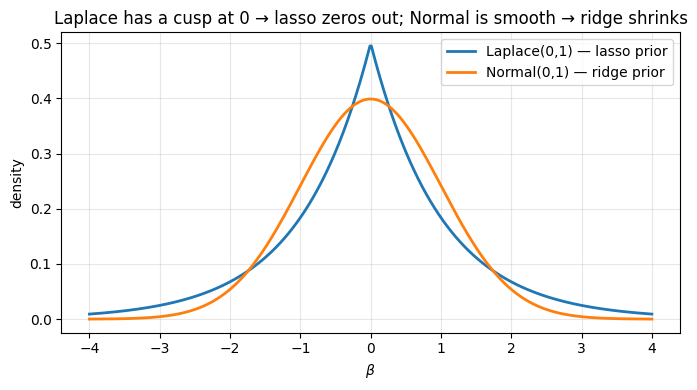

In [1]:
# Visual demo — not exam material.
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import laplace, norm

beta = np.linspace(-4, 4, 400)
plt.figure(figsize=(7, 4))
plt.plot(beta, laplace.pdf(beta, 0, 1), lw=2, label='Laplace(0,1) — lasso prior')
plt.plot(beta, norm.pdf(beta, 0, 1), lw=2, label='Normal(0,1) — ridge prior')
plt.xlabel(r'$\beta$')
plt.ylabel('density')
plt.title('Laplace has a cusp at 0 → lasso zeros out; Normal is smooth → ridge shrinks')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## §5.8 Exercises — chapter 5

> **E5.1.** Derive the lasso as MAP from scratch (Laplace prior + Gaussian likelihood).
>
> **E5.2.** State what happens to (a) training RSS, (b) test RSS, (c) coefficient variance, (d) coefficient bias, as $\lambda$ grows from 0 to $\infty$.
>
> **E5.3.** Why is standardization essential before applying lasso?
>
> **E5.4.** Why does lasso produce exactly-zero coefficients while ridge does not?
>
> **E5.5.** In Assignment 3, forward stepwise (30 features) achieved test RSS $\approx 2$ while lasso with $\approx 30$ non-zero features had test RSS $\approx 140$. Explain the gap.


### Solutions — chapter 5

**S5.1.** See §5.5. End with $\hat\beta_{\text{MAP}} = \arg\min \text{RSS} + (2\sigma^2/b)\|\beta\|_1$.

**S5.2.** (a) Training RSS monotonically **rises** as $\lambda$ grows (more constrained → worse training fit). (b) Test RSS is U-shaped — best at some intermediate $\lambda^\star$. (c) Variance shrinks (smaller coefficients in a smaller family). (d) Bias grows (from 0 at OLS to maximum at $\hat\beta = 0$).

**S5.3.** The L1 (or L2) penalty is unit-sensitive. Without scaling, a feature measured in large units will have naturally smaller coefficients and be penalized less, retained preferentially regardless of its signal. Standardizing all features to mean 0, variance 1 makes the penalty treat them equally.

**S5.4.** Geometrically, the L1 constraint has corners on the axes, so the optimal RSS-ellipse contact often happens at a corner (some $\beta_j = 0$). The L2 constraint is smooth, so optimal contact is generically interior.

**S5.5.** Lasso shrinks coefficients toward zero — the fitted portfolio's total weight sums to ~0.98 rather than 1, so it systematically under-tracks. Forward stepwise uses **unshrunken** OLS coefficients on its selected features, so it can match levels exactly. In time-series tracking tasks, shrinkage hurts out-of-sample precisely because the test-period levels differ from training.


---

# Chapter 6 — Model Selection (CV, AIC, BIC, Stepwise, TimeSeriesSplit)

## §6.1 The problem

Fitting and evaluating on the same data gives optimistic error (training error is monotonically non-increasing in model complexity). We need unbiased estimates of **generalization error** to choose hyperparameters ($\lambda$, $K$ in KNN, which features to include) without touching the final test set.

Three approaches appear in this course: (1) hold-out, (2) cross-validation, (3) information criteria (AIC, BIC).


## §6.2 Hold-out (train / validation / test)

Split the data three ways:
- **Training set** (~60%): fit candidate models.
- **Validation set** (~20%): pick the best hyperparameter.
- **Test set** (~20%): final, untouched evaluation.

Fast and simple; wastes data (each model sees only 60%). In low-data regimes, cross-validation is preferred.


## §6.3 $K$-fold cross-validation — mechanics

Split the training data into $K$ roughly-equal folds. For each fold $k = 1, \ldots, K$:
- Train on the other $K-1$ folds ($(K-1)n/K$ rows).
- Evaluate error on fold $k$ ($n/K$ rows).

CV loss = mean of the $K$ fold losses. Pick the hyperparameter that minimizes it.

### Arithmetic you must be able to do on the exam

| quantity | formula | example ($n = 1000$, $K = 5$) |
|---|---|---|
| # fits | $K$ | 5 |
| rows per fit | $n(K-1)/K$ | 800 |
| rows per val fold | $n/K$ | 200 |

**Gotcha.** If you're also tuning $\lambda$ over $G$ grid values, total fits = $K \times G$.


## §6.4 CV-min vs the 1-SE rule

Let $\overline{\text{CV}}(\lambda_g)$ = mean CV loss at $\lambda_g$, and $\text{SE}(\lambda_g) = \text{sd}_k(\text{CV}_k)/\sqrt K$.

- **CV-min:** pick $\lambda^\star = \arg\min \overline{\text{CV}}$.
- **1-SE rule:** pick the **largest** $\lambda$ whose $\overline{\text{CV}} \le \overline{\text{CV}}_{\min} + \text{SE}_{\min}$. Gives a more parsimonious, comparably-good model.

### Motivation for 1-SE
The CV curve is estimated with noise; many $\lambda$ values near the minimum are statistically indistinguishable. Picking the simplest model among those indistinguishable ones reduces variance and often generalizes a touch better.

Assignment 3 Q5 showed: CV-min picked 17 stocks (test MSE 0.18), CV-1se picked 7 stocks (test MSE 0.21). The 1-SE model is dramatically more parsimonious at tiny error cost.


## §6.5 AIC and BIC

**Akaike Information Criterion.**
$$\text{AIC} = -2\,\ell(\hat\beta) + 2k.$$

**Bayesian Information Criterion.**
$$\text{BIC} = -2\,\ell(\hat\beta) + k\log n.$$

Where $k$ is the number of fit parameters. Lower is better. Choose $\lambda$ (or feature subset) that minimizes the criterion.

### AIC vs BIC
- BIC penalizes complexity more than AIC whenever $\log n > 2$, i.e., $n > e^2 \approx 7.4$. For anything realistic, BIC prefers smaller models.
- BIC is *consistent* (picks the true model as $n \to \infty$ under the right assumptions); AIC is *prediction-optimal* asymptotically.
- `LassoLarsIC(criterion='aic' or 'bic')` picks $\lambda$ by sliding along the lasso path to the minimum of the criterion.

### Failure mode on non-iid data
Both AIC and BIC use raw $n$ as the \"amount of information.\" With autocorrelated data (time series), the *effective* sample size is far smaller than $n$. Both criteria therefore **under-penalize complexity** and pick models that are too big — in Assignment 3 Q5, AIC chose 313 stocks, BIC 219; CV chose 17. CV sidesteps this because it estimates generalization error empirically.


## §6.6 Forward stepwise selection

**Algorithm.**
- Start: feature set = empty.
- At each step: try adding each remaining feature one at a time; pick the one that reduces training RSS the most.
- Stop after a target $k$ features.

Each step fits $O(p)$ OLS regressions; selecting $k$ features is $O(kp)$ fits. Assignment 3 Q4: $k = 30$, $p \approx 450$ ⇒ ~13,500 OLS fits in ~18s.

**Key property.** Uses **unshrunken** OLS coefficients on the selected features. Contrast with lasso, which uses shrunken coefficients.

**Caveat.** Greedy — not guaranteed to find the global best subset of size $k$.

### Forward stepwise on hand
> *Candidates* {A, B, C, D, E}. After step 1, RSS by feature: A=330, B=350, C=320, D=340, E=360.
>
> Picked: **C** (lowest RSS 320).
> After step 2, RSS by remaining feature *given C is already in*: A=310, B=305, D=308, E=315.
> Picked: **B** (lowest 305). Step 2 selected set: {C, B}.


## §6.7 TimeSeriesSplit — CV that respects time

Shuffled $K$-fold places future observations in training folds and past observations in validation folds — **look-ahead leakage**. For time series we use an **expanding-window** split.

With $n_{\text{splits}} = K$ and $n$ ordered observations, fold $k$ trains on the first $n k/(K+1)$ rows and validates on the next block:

| fold | train | val |
|---|---|---|
| 1 | 0..$n/(K+1)$ | next block |
| 2 | 0..$2n/(K+1)$ | next block |
| ... | | |
| $K$ | 0..$Kn/(K+1)$ | last block |

Every validation set is **strictly after** its training set. No leakage, realistic estimate of out-of-sample error for a time-series model.


## §6.8 Exercises — chapter 6

> **E6.1.** With $n = 500$, $K = 10$: (a) how many fits does CV require? (b) how many rows does each use?
>
> **E6.2.** Two models on $n = 1000$ rows. Model 1: $\ell = -400$, $k = 5$. Model 2: $\ell = -395$, $k = 15$. Which does BIC prefer?
>
> **E6.3.** CV mean losses across $\lambda$ = {0.001, 0.01, 0.1, 1}: 0.18, 0.16, 0.17, 0.30. Minimum SE at the minimum = 0.015. Which $\lambda$ does CV-min pick? Which does 1-SE pick?
>
> **E6.4.** Why shouldn't you use shuffled $K$-fold CV on stock-price data?
>
> **E6.5.** Forward stepwise has selected {A, C, F}. After step 4, RSS by remaining feature: B=100, D=120, E=140, G=105. Which enters? What is the new RSS?


### Solutions — chapter 6

**S6.1.** (a) 10 fits. (b) $(K-1)n/K = 9 \cdot 500 / 10 = 450$ rows per fit.

**S6.2.** BIC = $-2\ell + k\log n$. $\log(1000) \approx 6.908$.
- Model 1: $800 + 5 \cdot 6.908 = 800 + 34.5 = 834.5.$
- Model 2: $790 + 15 \cdot 6.908 = 790 + 103.6 = 893.6.$

Lower is better, so **BIC prefers Model 1**.

**S6.3.** CV-min: $\lambda = 0.01$ (mean loss 0.16 is lowest). 1-SE threshold = $0.16 + 0.015 = 0.175$. Eligible: 0.01 (0.16), 0.1 (0.17). 1-SE picks the **largest**: $\lambda = 0.1$.

**S6.4.** Shuffling places future observations in training folds and past in validation. This *leaks* future information into training, producing an optimistic CV error estimate — the fitted model will look better than it really is when deployed in forward time. Use `TimeSeriesSplit` instead.

**S6.5.** **B** enters (RSS 100 is lowest). New RSS = 100. Selected set: {A, C, F, B}.


---

# Chapter 7 — Classification Evaluation

## §7.1 The confusion matrix

With predicted labels $\hat y_i = \mathbb 1(\hat p_i > t)$:

|  | Predicted 0 | Predicted 1 |
|---|---|---|
| **Actual 0** | TN | FP |
| **Actual 1** | FN | TP |

**Totals.** $n_P = TP + FN$ (true positives + false negatives = actually positive); $n_N = TN + FP$ (actually negative).

**First exam move.** *Label the axes.* The #1 cause of lost points is swapping actual / predicted.


## §7.2 The six rates

| name | formula | what it answers | mnemonic |
|---|---|---|---|
| Accuracy | $(TP+TN)/n$ | \"what fraction of predictions are right?\" | over everyone |
| **Sensitivity = TPR = Recall** | $TP / n_P$ | \"of the positives, what fraction did I catch?\" | *within the positives* |
| **Specificity = TNR** | $TN / n_N$ | \"of the negatives, what fraction did I correctly dismiss?\" | *within the negatives* |
| FPR | $FP / n_N = 1 - \text{TNR}$ | \"of the negatives, what fraction did I falsely alarm on?\" | *within the negatives* |
| FNR | $FN / n_P = 1 - \text{TPR}$ | \"of the positives, what fraction did I miss?\" | *within the positives* |
| Precision (PPV) | $TP / (TP + FP)$ | \"of the ones I flagged, what fraction are real?\" | *within the flagged* |

**Rates are not symmetric.** TPR and TNR use different denominators. Sensitivity rises when you predict \"1\" more often; specificity falls. There is no single rate that captures both — which is why we study ROC.


## §7.3 Worked arithmetic

Confusion matrix from Midterm Practice Concept 2:

|  | Predicted 0 | Predicted 1 |
|---|---|---|
| Actual 0 | 80 | 20 |
| Actual 1 | 30 | 70 |

- $TN = 80, FP = 20, FN = 30, TP = 70.$
- $n = 200$, $n_P = 100$, $n_N = 100.$
- **Accuracy** = $(70 + 80)/200 = 0.75.$
- **Sensitivity** = $70/100 = 0.70.$
- **Specificity** = $80/100 = 0.80.$
- FPR = 0.20, FNR = 0.30.
- Precision = $70 / (70 + 20) = 70/90 \approx 0.778.$


## §7.4 Base-rate effect (why imbalanced classes are hard)

If the positive class is rare ($\pi \ll 0.5$) and the default threshold is $t = 0.5$, most observations have $\hat p < 0.5$ and are predicted 0. This gives:
- Very high **specificity** (correctly dismissing negatives is easy — say \"0\" all the time).
- Very low **sensitivity** (catching the rare positives is hard).

This is **not** a sign of a broken classifier — it's a base-rate artifact. The fix is to lower the threshold (see §7.7–7.8).

Assignment 4 Q6: Bud Light buyers are 30% of the data. At $t = 0.5$, sensitivity = 0.14, specificity = 0.95. Classic base-rate effect.


## §7.5 ROC curve — intuition

A classifier outputs $\hat p_i$. If we set a **high threshold**, we only predict \"1\" for the most confident observations — few false positives, few true positives. If we set a **low threshold**, we predict \"1\" aggressively — many true positives, but many false positives too.

**ROC** plots TPR (sensitivity) against FPR ($1 -$ specificity) as we sweep the threshold from high to low. Each point on the curve = one threshold.

- Good ranker: curve bows toward the upper-left (high TPR at low FPR).
- Random ranker: diagonal.
- Perfect ranker: (0,1) step — TPR=1 at FPR=0.

### ROC is threshold-free
It summarizes the quality of the *ranking* (does the model give higher scores to positives than negatives?), independent of the specific threshold you pick.


## §7.6 Constructing an ROC by hand

**Algorithm.**
1. Sort observations by predicted probability $\hat p_i$, descending.
2. Sweep $t$ from high (nothing flagged) to low (everything flagged).
3. At each $t$, classify $\hat y_i = \mathbb 1(\hat p_i > t)$ and compute (FPR, TPR).
4. Plot.

### Step-through on the slide-17 10-point example

| $i$ | $y_i$ | $\hat p_i$ |
|---|---|---|
| 1 | 1 | 0.92 |
| 2 | 0 | 0.83 |
| 3 | 1 | 0.78 |
| 4 | 1 | 0.61 |
| 5 | 0 | 0.55 |
| 6 | 1 | 0.44 |
| 7 | 0 | 0.37 |
| 8 | 1 | 0.21 |
| 9 | 0 | 0.18 |
| 10 | 0 | 0.09 |

$n_P = 5$, $n_N = 5$.

Walking the threshold from highest to lowest (adding one observation to the \"predict 1\" set at each step):

| new row added | set | TP | FP | TPR | FPR |
|---|---|---|---|---|---|
| 1 ($y=1$) | {1} | 1 | 0 | 0.2 | 0.0 |
| 2 ($y=0$) | {1,2} | 1 | 1 | 0.2 | 0.2 |
| 3 ($y=1$) | {1,2,3} | 2 | 1 | 0.4 | 0.2 |
| 4 ($y=1$) | {1..4} | 3 | 1 | 0.6 | 0.2 |
| 5 ($y=0$) | {1..5} | 3 | 2 | 0.6 | 0.4 |
| 6 ($y=1$) | {1..6} | 4 | 2 | 0.8 | 0.4 |
| 7 ($y=0$) | {1..7} | 4 | 3 | 0.8 | 0.6 |
| 8 ($y=1$) | {1..8} | 5 | 3 | 1.0 | 0.6 |
| 9 ($y=0$) | {1..9} | 5 | 4 | 1.0 | 0.8 |
| 10 ($y=0$) | {1..10} | 5 | 5 | 1.0 | 1.0 |

Connecting the (FPR, TPR) points gives the ROC. This is a strong ranker: TPR hits 0.6 while FPR is still 0.2; TPR hits 1.0 by the time FPR = 0.6.


## §7.7 AUC

$$\text{AUC} = \int_0^1 \text{TPR}(\text{FPR})\,d\text{FPR}.$$

**Three equivalent interpretations.**
1. **Geometric.** Area under the ROC curve.
2. **Probabilistic.** $\Pr(\hat p_{i:y=1} > \hat p_{j:y=0})$ — the probability a random positive outscores a random negative.
3. **Ranking.** The Mann–Whitney U statistic rescaled to $[0,1]$.

**Benchmarks.** 0.5 = chance; 0.7 = useful; 0.85+ = strong; 1.0 = perfect.

AUC is **threshold-free** — it measures how well the model *orders* observations, independent of where you put $t$.


## §7.8 Decision-theoretic threshold (the business problem)

If the cost / benefit of acting depends on the true class, the optimal threshold is *not* 0.5.

**Action-payoff matrix.**

|  | True $Y = 1$ | True $Y = 0$ |
|---|---|---|
| Act | $+B_{TP}$ | $-C_{FP}$ |
| Don't | 0 | 0 |

(If don't-act has non-zero costs, fill those in; the derivation generalizes — see §7.10.)

**Expected payoff of acting at $\hat p = p$:**
$$\mathbb E[\text{act}\mid p] = B_{TP}\,p - C_{FP}(1-p) = (B_{TP} + C_{FP})\,p - C_{FP}.$$

**Act iff** $\mathbb E[\text{act}\mid p] > 0$, i.e., iff
$$p > \frac{C_{FP}}{B_{TP} + C_{FP}}.$$

$$\boxed{\;t^\star = \frac{C_{FP}}{B_{TP} + C_{FP}}.\;}$$

**Intuition.** $t^\star$ is low when the **gain on a true positive** is large relative to the **cost of a false positive** — you are willing to act on weaker evidence.

### Assignment 4 Q8 — mailer example
$C_{FP} = 0.50$ (send cost), $B_{TP} = 2.00 - 0.50 = 1.50$. $t^\star = 0.50/(0.50 + 1.50) = 0.25.$


## §7.9 Effect of lowering the threshold

**Universal rule.** $t \downarrow \Rightarrow$ sensitivity $\uparrow$, specificity $\downarrow$. $t \uparrow \Rightarrow$ opposite.

*Why.* Predicting 1 on more observations:
- catches more true positives (TPR ↑),
- but also catches more false positives (FPR ↑ = specificity ↓).

### Assignment 4 Q8 before/after
- $t = 0.5$: sensitivity = 0.14, specificity = 0.95.
- $t = 0.25$: sensitivity = 0.73, specificity = 0.47.

Moving from 0.5 to 0.25 tripled realised profit per household (from \$0.045 to \$0.141).


## §7.10 Worked derivation — tutoring problem (review slide 16)

A university offers a free tutoring session to at-risk students. Let $p$ = probability the student **completes the course without tutoring**.

Payoffs (review slide 16):

|  | Completes w/o tutoring ($p$) | Does not complete w/o tutoring ($1-p$) |
|---|---|---|
| Tutor | $-30$ | $+90$ |
| No tutor | $0$ | $-25$ |

*Assumption: every tutored student completes.*

**Step 1 — expected payoffs.**
$$\mathbb E[\text{tutor}\mid p] = -30 p + 90(1-p) = 90 - 120 p.$$
$$\mathbb E[\text{no tutor}\mid p] = 0 \cdot p + (-25)(1-p) = -25 + 25 p.$$

**Step 2 — tutor iff expected-payoff difference > 0.**
$$(90 - 120 p) - (-25 + 25 p) > 0$$
$$115 - 145 p > 0$$
$$p < 115/145 = 23/29 \approx 0.793.$$

$$\boxed{\;t^\star = 23/29 \approx 0.79.\;}$$

Tutor every student with $p <$ 0.79. Compared to $t = 0.5$, we tutor *more* students (lower threshold on $p$).

**Direction of sensitivity / specificity for \"detecting non-completers\".** A non-completer has $p$ *low*. At the new threshold (tutor if $p < 0.79$), we correctly flag more non-completers as \"tutor\" — **sensitivity (for detecting non-completers) ↑**. But we also flag many completers as \"tutor\" — **specificity ↓**.


## §7.11 Youden's J

$J(t) = \text{TPR}(t) - \text{FPR}(t)$. The threshold maximizing $J$ is the **point on the ROC furthest above the diagonal**. Balanced — treats sensitivity and specificity with equal weight. Useful when no asymmetric cost is specified.


## §7.12 Exercises — chapter 7

> **E7.1.** Confusion: TP=80, FP=20, FN=10, TN=90. Compute accuracy, sensitivity, specificity, precision.
>
> **E7.2.** Explain in one sentence why, at $t = 0.5$, a classifier with 10% base rate usually has low sensitivity and high specificity.
>
> **E7.3.** Given: $C_{FP} = 5$, $B_{TP} = 15$, no other costs. Derive $t^\star$.
>
> **E7.4.** ROC construction. $y = [1, 1, 0, 0]$, $\hat p = [0.9, 0.3, 0.7, 0.1]$. Compute (FPR, TPR) at $t = 0.5$ and at $t = 0.2$.
>
> **E7.5.** Derive the optimal threshold for the tutoring problem (§7.10) and explain the direction of sensitivity for detecting non-completers, going from $t = 0.5$ to $t = t^\star$.
>
> **E7.6.** A bank screens loan applications for fraud. A false accusation costs $C_{FP} = 100$ (customer service). A caught fraud saves $B_{TP} = 400$. A missed fraud (false negative) costs $C_{FN} = 300$. What is $t^\star$?


### Solutions — chapter 7

**S7.1.** $n_P = 90$, $n_N = 110$, $n = 200$.
- Accuracy = $170/200 = 0.85.$
- Sensitivity = $80/90 \approx 0.889.$
- Specificity = $90/110 \approx 0.818.$
- Precision = $80/(80+20) = 0.800.$

**S7.2.** With only 10% of observations being positive, most $\hat p$ values are below 0.5, so the model predicts 0 almost always — catching most true negatives (high specificity) but missing most true positives (low sensitivity). It's a *base-rate effect*, not a training defect.

**S7.3.** $t^\star = C_{FP}/(B_{TP} + C_{FP}) = 5/(5+15) = 1/4 = 0.25.$

**S7.4.** At $t = 0.5$, $\hat y = [1, 0, 1, 0]$. TP = 1 (obs 1), FN = 1 (obs 2), FP = 1 (obs 3), TN = 1 (obs 4). $n_P = 2, n_N = 2$. TPR = 0.5, FPR = 0.5.
At $t = 0.2$, $\hat y = [1, 1, 1, 0]$. TP = 2, FN = 0, FP = 1, TN = 1. TPR = 1.0, FPR = 0.5.

**S7.5.** See §7.10. $t^\star = 23/29$. Lowering threshold means more students are tutored; among true non-completers (low $p$), more are correctly flagged → sensitivity ↑.

**S7.6.** Include the cost of a false negative in the payoff matrix:

|  | True $Y = 1$ | True $Y = 0$ |
|---|---|---|
| Act (block) | $+400$ | $-100$ |
| Don't | $-300$ | $0$ |

$\mathbb E[\text{act}] = 400 p - 100 (1-p)$.
$\mathbb E[\text{don't}] = -300 p + 0$.

Act iff difference > 0: $400 p - 100 + 100 p + 300 p > 0 \Leftrightarrow 800 p > 100 \Leftrightarrow p > 0.125.$

$t^\star = 0.125.$ (Check with a generalized formula: $t^\star = (C_{FP} - \text{regret}_{\text{don't, Y=0}})/((B_{TP} - \text{regret}_{\text{don't, Y=1}}) + (C_{FP} - \text{regret}_{\text{don't, Y=0}}))$ where the regrets are the don't-act payoffs; here $(100-0)/((400-(-300)) + (100-0)) = 100/800 = 0.125$.)


---

# Chapter 8 — KNN and Non-Parametric Methods

## §8.1 The KNN rule

For a new point $x_{\text{new}}$, find its $K$ nearest training neighbours $(x_{i_1}, y_{i_1}), \ldots, (x_{i_K}, y_{i_K})$ under a chosen distance metric. Predict:

- **Classification:** majority vote $\hat y = \arg\max_j\,\tfrac 1 K \sum_k \mathbb 1\{y_{i_k} = j\}.$
- **Regression:** average $\hat y = \tfrac 1 K \sum_k y_{i_k}.$

**Non-parametric.** No finite parameter vector $\beta$. The **entire training set** is the model.

**No training phase.** All the work happens at prediction time.


## §8.2 Distance metrics

### Euclidean $L_2$
$$d(\mathbf u, \mathbf v) = \sqrt{\sum_j (u_j - v_j)^2}.$$

Use with **continuous** features — but only after scaling (§8.4). Unscaled Euclidean is dominated by whichever feature has the largest units.

### Hamming (for categorical)
$$d_H(\mathbf u, \mathbf v) = \sum_j \mathbb 1\{u_j \ne v_j\}.$$

Counts the number of coordinates at which two vectors disagree.

**When to use Hamming.** Any time your features are categorical — in particular 0/1 dummy-encoded features. Hamming on dummies is naturally scale-free.

### Why Hamming for one-hot encoded dummies
Two households differing on exactly one level of `income` (say, `20-60k` vs `60-100k`) have Hamming distance 1 regardless of which two levels they differ on. Euclidean on dummies gives $\sqrt 2$ for any single-level disagreement — same as Hamming up to rescaling, but with no intuitive interpretation.

Assignment 4 used Hamming on 9 household demographic dummies.


## §8.3 Bias–variance in $K$

| $K$ | bias | variance | training accuracy | test accuracy | boundary |
|---|---|---|---|---|---|
| 1 | 0 | max | 100% (if rows unique) | often lowest | very jagged |
| small (3, 5) | low | high | high | moderate | wiggly |
| moderate | moderate | moderate | moderate | often best | smooth |
| $n/10$ | high | low | moderate | declining | broad |
| $n$ | max (modal class) | 0 | base rate | base rate | constant |

### Training accuracy at $K = 1$
With distinct training rows, each point's nearest neighbour is itself (distance 0) — so the model predicts its own label. Training accuracy = 1. The classic signature of overfitting.

### $K$ is the complexity knob
- Small $K$ = flexible model = high variance = risk of overfit.
- Large $K$ = rigid model = high bias = risk of underfit.
- **Direction is opposite** to $\lambda$ in lasso: small $K \leftrightarrow$ small $\lambda$ (flexible); large $K \leftrightarrow$ large $\lambda$ (rigid).


## §8.4 Feature scaling

Euclidean distance is scale-sensitive. Feature with variance 100 dominates feature with variance 1 — the classifier effectively ignores the smaller-variance feature.

**Rule.** Always **standardize** every continuous feature to mean 0, variance 1 before Euclidean KNN.

Hamming on 0/1 dummies is naturally scale-invariant — no need to scale.


## §8.5 Non-linear boundaries

KNN's decision boundary is the **union of Voronoi cells** around each training point. It can take arbitrary shape — it does *not* require the boundary to be a hyperplane.

This is why KNN can beat logistic regression on problems with non-linear structure (e.g., two positive clusters surrounded by negatives).

*Assignment 4 Q3c* — KNN with $K=3$ achieved test accuracy ~0.47 on beer-brand prediction; multinomial logistic (linear boundary) reached only ~0.32.


## §8.6 Computational cost and curse of dimensionality

- **Prediction cost.** $O(np)$ per query (scan all $n$ training points, each of dimension $p$). Tree-based indexes (KD-tree, ball tree) help when $p$ is modest.
- **Curse of dimensionality.** In high dimensions, all points become roughly equidistant — \"nearest neighbours\" carry less information. KNN degrades as $p$ grows.
- **No model to interpret.** KNN doesn't give coefficients; you can't say \"feature 3 matters 2× more than feature 7\".


## §8.7 Hand KNN on a toy dataset

Training data:

| $i$ | $x_1$ | $x_2$ | $y$ |
|---|---|---|---|
| 1 | 0 | 0 | A |
| 2 | 0 | 1 | A |
| 3 | 1 | 0 | B |
| 4 | 2 | 2 | B |
| 5 | 3 | 1 | B |

Query $x_{\text{new}} = (1, 1)$.

Euclidean distances:
- $d_1 = \sqrt{(1-0)^2 + (1-0)^2} = \sqrt 2 \approx 1.414$.
- $d_2 = \sqrt{1^2 + 0^2} = 1$.
- $d_3 = \sqrt{0^2 + 1^2} = 1$.
- $d_4 = \sqrt{1^2 + 1^2} = \sqrt 2 \approx 1.414$.
- $d_5 = \sqrt{2^2 + 0^2} = 2$.

### By $K$:
- **$K = 1$.** Tie between rows 2 and 3 (both at distance 1). Label depends on tiebreak — **A or B**.
- **$K = 3$.** Three smallest distances include rows 2, 3, and one of {1, 4} (tied at $\sqrt 2$). Depending on tie-breaking, labels are {A, B, A} → **A** or {A, B, B} → **B**.
- **$K = 5$.** All five points → labels {A, A, B, B, B} → **B**.

**Moral.** KNN is sensitive to ties; larger $K$ is more stable.


## §8.8 Exercises — chapter 8

> **E8.1.** Which is non-parametric: logistic, linear, KNN, lasso?
>
> **E8.2.** Explain why decreasing $K$ in KNN increases overfitting.
>
> **E8.3.** A dataset has feature `age` (values 20–80) and feature `income` (values 20,000–200,000). Without standardization, which feature dominates Euclidean distance?
>
> **E8.4.** Compare KNN and logistic regression on (a) training cost, (b) interpretability, (c) ability to fit non-linear boundaries.
>
> **E8.5.** What is the training accuracy of $K = 1$ KNN on a dataset with unique feature vectors?
>
> **E8.6.** Why is Hamming the natural distance for a one-hot encoded categorical feature?


### Solutions — chapter 8

**S8.1.** KNN. (All the others are parametric — they have a finite-dim $\beta$.)

**S8.2.** Smaller $K$ means the prediction depends on fewer training examples — the model chases local noise rather than averaging it out. Low bias but very high variance → overfits training data, generalizes poorly.

**S8.3.** Income (much larger scale, ~1000× larger range). A 1-year age difference is distance ~1, but a \$1000 income difference is also distance ~1000 — the distance is dominated by income.

**S8.4.** (a) KNN: no training. Logistic: optimization (gradient descent). (b) KNN: no interpretable coefficients. Logistic: log-odds interpretation per coefficient. (c) KNN: naturally non-linear (Voronoi). Logistic: linear boundary (unless you add polynomial / interaction features).

**S8.5.** 100%. Each training point's nearest neighbour is itself (distance 0), and its label matches itself.

**S8.6.** Two vectors differing on exactly one categorical axis have Hamming distance 1, regardless of which axis or which levels. This aligns with the intuitive notion of \"how many categorical coordinates do these two households disagree on?\" Euclidean on 0/1 dummies gives $\sqrt{2 \cdot (\text{number of disagreements})}$ — same ordering as Hamming, just a rescaling, and without the clean interpretation.


---

# Chapter 9 — Synthesis: Choosing a Method

## §9.1 Supervised, unsupervised, reinforcement

| paradigm | data available | goal | example |
|---|---|---|---|
| Supervised | $(x_i, y_i)$ | predict $y$ from $x$ | this entire course |
| Unsupervised | $x_i$ only | extract low-dim structure | clustering stocks, dimensionality reduction |
| Reinforcement | states, actions, rewards over time | maximize cumulative reward | game-playing, dynamic pricing |

**Midterm scope is supervised.** Unsupervised / reinforcement are *post-midterm* topics.


## §9.2 Parametric vs non-parametric

| | parametric (linear / logistic / lasso) | non-parametric (KNN) |
|---|---|---|
| Model form | fixed with finite $\beta$ | no explicit model — rely on the data |
| Training | fit $\beta$ via MLE / penalized optimization | store data |
| Prediction | $O(p)$ per query | $O(np)$ per query |
| Interpretability | coefficients have direct meaning | none |
| Flexibility | limited to the assumed functional form | unlimited (local) |
| Small-$n$ behaviour | stable | noisy |
| Large-$p$ behaviour | robust with regularization | curse of dimensionality |


## §9.3 Pros / cons (from review slides 8, 9)

### When the true model is linear

| method | pro | con |
|---|---|---|
| Linear regression | **best** with small $p$ | overfits with large $p$ |
| Lasso | less likely to overfit with large $p$ | shrinkage bias; choice of $\lambda$ |
| KNN | flexible fit | high variance |

### When the true model is unknown

| method | pro | con |
|---|---|---|
| Linear regression | interpretable | non-linear features lead to overfitting |
| Lasso | can safely include many non-linear features | choice of $\lambda$; hand-engineer features |
| KNN | non-linear boundaries; simple | computationally intensive; doesn't scale with $p$; no interpretability |


## §9.4 Decision tree for method choice

```
Continuous y?
├── yes → linear regression
│         ├── small p: plain OLS
│         ├── large p: lasso / ridge / stepwise
│         └── worry about OVB & confounding for causal claims
│
└── no (categorical y)?
    ├── binary y?
    │   ├── yes → logistic regression (or probit)
    │   │         ├── want interpretability: logistic (log-odds)
    │   │         └── Gaussian-style assumptions: probit
    │   └── no (K > 2 classes) → multinomial logistic (softmax)
    │
    └── flexible / non-linear structure?
        └── KNN (pick K via CV, standardize or use Hamming)
```


## §9.5 Visualization grammar (review slide 5)

|  | 1 variable | 2 variables |
|---|---|---|
| Continuous | histogram | scatterplot |
| Categorical | bar chart | stacked bar |
| Mixed | — | boxplot |

Specialized:
- Time-series continuous: **line plot**.
- Geographic: **choropleth** via `geopandas`.
- Categorical-categorical: also **mosaic** or **heatmap**.


---

# Chapter 10 — Simulated Midterm

**Timing goal: 90 minutes.**

- Part I: 7 multiple choice — 7 min.
- Part II: 5 concept checks — 20 min.
- Part III: 2 short answer — 40 min.
- Buffer / review — 23 min.

Work each problem by hand before peeking at the answer. Answers appear in the cell immediately after each question.


## Part I — Multiple choice (7 × 2 = 14 points)

**1.** A model has training $R^2 = 0.92$ and test $R^2 = 0.31$. The main concern is:

(A) underfitting (B) overfitting (C) high bias (D) data leakage

**2.** Which quantity is *minimized* when fitting a linear regression?

(A) log-likelihood (B) residual sum of squares (C) AIC (D) classification error

**3.** In logistic regression, $\hat\beta_j$ is:

(A) the change in probability per unit change in $x_j$
(B) the change in log-odds per unit change in $x_j$
(C) the change in odds per unit change in $x_j$
(D) the marginal effect of $x_j$ on $y$

**4.** As $\lambda$ grows in a lasso regression:

(A) more coefficients become exactly zero
(B) training RSS falls
(C) coefficient variance grows
(D) the model becomes equivalent to OLS

**5.** Which method is **non-parametric**?

(A) linear regression (B) logistic regression (C) lasso (D) KNN

**6.** In KNN, *decreasing* $K$ generally:

(A) increases bias (B) decreases variance (C) increases overfitting (D) smooths the boundary

**7.** With $n = 800$ and $K = 8$, $K$-fold cross-validation requires how many model fits, each using how many rows?

(A) 8 fits, 100 rows (B) 8 fits, 700 rows (C) 7 fits, 100 rows (D) 1 fit, 800 rows


### MC answers

1. **B** (overfitting — huge train-vs-test gap)
2. **B** (RSS; equivalent to maximizing Gaussian likelihood)
3. **B** (log-odds — classic exam trap)
4. **A** (lasso zeros coefficients as $\lambda$ grows)
5. **D** (KNN; others are parametric)
6. **C** (smaller $K$ ⇒ more flexible ⇒ overfit)
7. **B** ($K=8$ fits, each using $n(K-1)/K = 700$ rows)


## Part II — Concept checks (5 × 4 = 20 points)

### C1. Logistic regression

The fitted model $\log\dfrac{\hat p}{1-\hat p} = -0.8 + 0.6\,x_1 - 1.1\,x_2.$

(a) Write $P(Y=1\mid x_1=1, x_2=0)$ as a number.
(b) Interpret $\hat\beta_1 = 0.6$ in terms of odds.


**C1 answer.**
(a) Log-odds at $(x_1=1, x_2=0)$ is $-0.8 + 0.6 = -0.2$. $p = 1/(1 + e^{0.2}) = 1/(1 + 1.221) \approx 0.450.$
(b) A one-unit ↑ in $x_1$ multiplies the odds by $e^{0.6} \approx 1.82$ (an 82% increase in odds).


### C2. Confusion matrix

|  | Predicted 0 | Predicted 1 |
|---|---|---|
| Actual 0 | 150 | 50 |
| Actual 1 | 30 | 70 |

Compute accuracy, sensitivity, specificity, and precision.


**C2 answer.**
$n = 300$, $n_P = 100$, $n_N = 200$. TP = 70, FN = 30, FP = 50, TN = 150.
- Accuracy = $220/300 \approx 0.733.$
- Sensitivity = $70/100 = 0.70.$
- Specificity = $150/200 = 0.75.$
- Precision = $70/(70+50) = 70/120 \approx 0.583.$


### C3. Lasso and standardization

Consider the objective
$$\sum_i (y_i - x_i'\beta)^2 + \lambda \sum_j |\beta_j|.$$
(a) Name the method.
(b) What happens as $\lambda \to 0$?
(c) Why is standardization important?


**C3 answer.**
(a) **Lasso.**
(b) As $\lambda \to 0$ the penalty vanishes and the solution approaches OLS.
(c) The penalty is unit-sensitive: features measured in larger units have naturally smaller coefficients and are retained preferentially. Standardizing each feature to mean 0, variance 1 makes the penalty treat all features equally — the fitted weights reflect signal strength, not units.


### C4. Decision threshold

An airline predicts $\hat p$ = probability a passenger misses their connection. Rebooking costs \$30; a missed connection caught in time saves \$180. Ignoring a missed connection costs \$90.

(a) Write the action-payoff matrix.
(b) Derive $t^\star$ on $\hat p$ above which rebooking is profitable.


**C4 answer.**

|  | True $Y=1$ (misses) | True $Y=0$ |
|---|---|---|
| Rebook | $180 - 30 = +150$ | $-30$ |
| Don't | $-90$ | $0$ |

$\mathbb E[\text{rebook}] = 150 p - 30(1-p) = 180 p - 30.$
$\mathbb E[\text{don't}] = -90 p.$

Rebook iff difference $> 0$:
$$180 p - 30 - (-90 p) > 0 \Leftrightarrow 270 p > 30 \Leftrightarrow p > 1/9 \approx 0.111.$$
$t^\star = 1/9.$


### C5. KNN

(a) Why can KNN produce non-linear decision boundaries?
(b) Explain why feature scaling is essential before Euclidean KNN.


**C5 answer.**
(a) KNN classifies each new point by the labels of its $K$ nearest training neighbours, with no global parametric form. The induced boundary is a union of Voronoi cells and can take arbitrary shape — no linear-in-$\beta$ constraint.
(b) Euclidean distance is scale-sensitive: a feature with variance 100 dominates a feature with variance 1 (distance $\approx$ 10× larger per unit). Without standardization, the nearest-neighbour search effectively ignores the smaller-variance feature. Standardizing every feature to unit variance gives all coordinates equal influence on the distance.


## Part III — Short answer (2 × 8 = 16 points)

### S1. Probit GLM (adapted from Midterm Practice 1.1)

Suppose $Y_i \in \{0, 1\}$ with $P(Y_i = 1\mid X_i) = \Phi(X_i'\beta)$, where $\Phi$ is the standard normal CDF. The sample is iid.

(a) Write the likelihood $L(\beta; Y, X)$ and log-likelihood $\ell(\beta; Y, X)$.
(b) With $\phi = \Phi'$, derive
$$S(\beta) = \frac{\partial \ell}{\partial \beta} = \sum_i \frac{\phi(X_i'\beta)(Y_i - \Phi(X_i'\beta))}{\Phi(X_i'\beta)(1 - \Phi(X_i'\beta))}\,X_i.$$
(c) Give one reason to prefer probit over logit.


**S1 answer.**

**(a)** Writing $p_i = \Phi(X_i'\beta)$, each observation contributes $p_i^{Y_i}(1-p_i)^{1-Y_i}$. iid gives
$$L(\beta) = \prod_i \Phi(X_i'\beta)^{Y_i} (1 - \Phi(X_i'\beta))^{1 - Y_i},$$
$$\ell(\beta) = \sum_i [Y_i \log \Phi(X_i'\beta) + (1-Y_i) \log(1 - \Phi(X_i'\beta))].$$

**(b)** Chain rule: $\partial \Phi(X_i'\beta) / \partial \beta = \phi(X_i'\beta) X_i$, so
$$\frac{\partial \log \Phi(X_i'\beta)}{\partial \beta} = \frac{\phi(X_i'\beta)}{\Phi(X_i'\beta)} X_i,\qquad \frac{\partial \log(1 - \Phi(X_i'\beta))}{\partial \beta} = -\frac{\phi(X_i'\beta)}{1 - \Phi(X_i'\beta)} X_i.$$
Therefore
$$S(\beta) = \sum_i\left[\frac{Y_i \phi(X_i'\beta)}{\Phi(X_i'\beta)} - \frac{(1-Y_i)\phi(X_i'\beta)}{1 - \Phi(X_i'\beta)}\right] X_i.$$
Combining over a common denominator $\Phi_i(1 - \Phi_i)$ (dropping arguments):
$$\frac{Y_i \phi (1 - \Phi) - (1-Y_i) \phi \Phi}{\Phi(1 - \Phi)} = \frac{\phi (Y_i - \Phi)}{\Phi(1 - \Phi)}.$$
$$\boxed{\;S(\beta) = \sum_i \frac{\phi(X_i'\beta)(Y_i - \Phi(X_i'\beta))}{\Phi(X_i'\beta)(1 - \Phi(X_i'\beta))} X_i.\;\blacksquare}$$

**(c)** Probit assumes Gaussian latent errors, natural if the unobservables aggregate many small independent shocks (CLT). It also plugs cleanly into other Gaussian models (e.g., Heckman selection). In practice logit and probit fit almost identically; the theoretical framing drives the choice.


### S2. Business decision problem

A consumer-goods firm has a logistic model that outputs $\hat p_i$ = probability customer $i$ will upgrade to the premium tier. Each targeted upsell email costs \$2 to send. If sent to a customer who upgrades: \$25 in expected revenue (net of cost: $+\$23$). If sent to a customer who doesn't upgrade: nothing gained (net $-\$2$).

(a) Write the action-payoff matrix.
(b) Derive $t^\star$ on $\hat p$ above which sending is profitable.
(c) Going from $t = 0.5$ to $t^\star$, does the classifier's sensitivity (for detecting upgraders) go up or down? Its specificity? Justify.
(d) At a base rate of 10% upgraders, would you expect sensitivity or specificity to be higher at $t = 0.5$? Why?


**S2 answer.**

**(a)**

|  | True $Y=1$ (upgrades) | True $Y=0$ |
|---|---|---|
| Send email | $+23$ | $-2$ |
| Don't send | $0$ | $0$ |

**(b)** $\mathbb E[\text{send} \mid p] = 23 p - 2(1-p) = 25 p - 2$. Send iff > 0:
$$25 p - 2 > 0 \Leftrightarrow p > 2/25 = 0.08.$$
$t^\star = 0.08$, or equivalently via the formula $t^\star = C_{FP}/(C_{FP} + B_{TP}) = 2/(2 + 23) = 2/25 = 0.08.$

**(c)** Lowering $t$ from 0.5 to 0.08 means sending emails much more aggressively. **Sensitivity ↑** (more true upgraders are flagged). **Specificity ↓** (more non-upgraders are also flagged). The trade-off is captured by moving along the ROC curve toward the top right.

**(d)** With 10% base rate, most customers have $\hat p$ well below 0.5. At $t = 0.5$ the classifier predicts \"don't send\" for almost everyone — high specificity (catching most true negatives), low sensitivity (missing most true upgraders). This is a base-rate effect, not a flaw of the classifier. It's the same phenomenon as Assignment 4 Q6 observed for Bud Light (base rate ~30%, sensitivity at $t = 0.5$ was 0.14).


## Scoring

**Out of 50.**

- 40–50: exam-ready. Trust your preparation.
- 30–39: solid foundations; re-read the specific chapter(s) for any mistake.
- below 30: revisit the foundations (chs 1–2), then re-attempt.


---

# Chapter 11 — Final Dense Review Sheet (copy onto paper)

*This section is designed to be transcribed — every formula, rule, and numerical shortcut you need in a single compact layout.*


## §11.1 Foundations

**Bayes.** $p(\theta \mid d) \propto p(d\mid \theta)\,p(\theta).$ Argmax drops the $p(d)$ constant.
**iid.** $p(y_1,\ldots,y_n \mid X,\beta) = \prod_i p(y_i \mid x_i, \beta).$
**Likelihood chain.** $L \to \ell = \log L \to \text{Dev} = -2\ell.$ All three share the same argmax/argmin in $\beta$.

**Densities.**

| | density | mean | var |
|---|---|---|---|
| Normal | $(1/\sigma\sqrt{2\pi})\exp(-(y-\mu)^2/2\sigma^2)$ | $\mu$ | $\sigma^2$ |
| Bernoulli | $p^y(1-p)^{1-y}$ | $p$ | $p(1-p)$ |
| Laplace | $(1/2b)\exp(-\lvert y\rvert/b)$ | $0$ | $2b^2$ |


## §11.2 Linear regression

**Model + MLE = OLS.** With Gaussian errors, $\hat\beta_{\text{MLE}} = \arg\min \text{RSS} = (X'X)^{-1}X'\mathbf y.$

**Metrics.** $\text{RSS} = \sum(\hat y - y)^2$, $\text{TSS} = \sum(y-\bar y)^2$, $R^2 = 1 - \text{RSS}/\text{TSS}$, $\text{MSE} = \text{RSS}/n$.

**Interpretation table.**

| form | 1 unit ↑ $x$ ⇒ |
|---|---|
| $y\sim x$ | $\beta$-unit change in $y$ |
| $\log y \sim x$ | $\approx 100\beta\%$ change in $y$ |
| $y \sim \log x$ | $1\%\ \Delta x \Rightarrow \beta/100$ unit change in $y$ |
| $\log y \sim \log x$ | elasticity: $1\%\ \Delta x \Rightarrow \beta\%\ \Delta y$ |

**Categorical.** Ref level absorbed in intercept; $\beta$ = difference from reference.

**Interaction $x_1\cdot x_2$.** Slope on $x_1$ = $\beta_1 + \beta_{12}x_2$. Always write both simple slopes.

**OVB.** $\text{sign(bias)} = \text{sign}(\beta_{\text{omit}}) \cdot \text{sign}(\text{corr}(x_{\text{in}}, x_{\text{omit}})).$

**Overfit signature.** Train $R^2 \gg$ test $R^2$.


## §11.3 Logistic / GLM

**Bernoulli likelihood.** $L = \prod p_i^{y_i}(1-p_i)^{1-y_i}$.
**Deviance.** $\text{Dev} = -2\sum[y\log p + (1-y)\log(1-p)].$
**Logit.** $p = \sigma(z) = 1/(1+e^{-z})$. $\sigma' = \sigma(1-\sigma).$
**Probit.** $p = \Phi(z)$, $\phi = \Phi'.$

**Log-odds interpretation.** $\log\tfrac{p}{1-p} = x'\beta.$ 1-unit ↑ $x_j$ ⇒ log-odds + $\beta_j$ ⇒ odds × $e^{\beta_j}.$ **Not** a change in probability.

**Logistic score.**
$$\frac{\partial \ell}{\partial \beta} = \sum (y_i - p_i) x_i.$$

**Probit score.**
$$S(\beta) = \sum \frac{\phi(x_i'\beta)(y_i - \Phi(x_i'\beta))}{\Phi(x_i'\beta)(1 - \Phi(x_i'\beta))} x_i.$$

**Multinomial.** $P(Y=k\mid x) = e^{x'\beta_k}/\sum_j e^{x'\beta_j}$. $\hat y = \arg\max_k x'\beta_k.$

**Gradient descent.** $\beta_{t+1} = \beta_t - \eta\nabla\text{Dev}(\beta_t).$ Stop at $|\beta_{t+1}-\beta_t| <$ tol.

*Logistic has no closed form; linear does.*


## §11.4 Regularization

**Lasso.** $\min \text{RSS} + \lambda\|\beta\|_1.$ $\lambda\uparrow$: more $\beta_j = 0$.
**Ridge.** $\min \text{RSS} + \lambda\|\beta\|_2^2.$ Shrinks, never exact zero.
**Standardize first.** Penalty is unit-sensitive.

**Bayesian MAP correspondence.**

| prior | MAP | $\lambda$ |
|---|---|---|
| Laplace$(0, b)$ | Lasso | $2\sigma^2/b$ |
| Normal$(0, \tau^2)$ | Ridge | $\sigma^2/\tau^2$ |

**MAP 4-step template.**
1. $\log$ posterior = $\log L + \log p + c$.
2. Gaussian likelihood ⇒ $-\text{RSS}/(2\sigma^2)$.
3. Plug in the prior; drop constants.
4. Multiply by $-2\sigma^2$ (flip sign), read off the penalty.

**Shrinkage bias.** Even selected features have shrunken coefficients ⇒ relaxed lasso (select, then refit OLS).


## §11.5 Model selection

**Forward stepwise.** Greedy: add best feature by training RSS at each step. Unshrunken coefficients.

**Information criteria.**
$$\text{AIC} = -2\ell + 2k,\qquad \text{BIC} = -2\ell + k\log n.$$
BIC > AIC penalty whenever $n > e^2 \approx 7.4$, so BIC favours smaller models.

**K-fold CV.** $K$ fits, each on $n(K-1)/K$ rows. Val fold size $n/K$.
**1-SE rule.** Pick largest $\lambda$ with CV loss $\le$ min + 1 SE.
**TimeSeriesSplit.** Expanding training window, val fold strictly after. No leakage.

**Why AIC/BIC fail on non-iid.** Raw $n$ overcounts information when observations are autocorrelated; both criteria under-penalize complexity.


## §11.6 Classification evaluation

**Confusion (label the axes!).**

|  | Pred 0 | Pred 1 |
|---|---|---|
| Act 0 | TN | FP |
| Act 1 | FN | TP |

**Rates.**

| rate | formula |
|---|---|
| accuracy | $(TP+TN)/n$ |
| sens = TPR = recall | $TP/n_P$ |
| spec = TNR | $TN/n_N$ |
| FPR | $FP/n_N = 1-$TNR |
| FNR | $FN/n_P = 1-$TPR |
| precision | $TP/(TP+FP)$ |

**Threshold direction.** $t \downarrow$: sens ↑, spec ↓. $t\uparrow$: opposite.

**ROC construction.** Sort by $\hat p$ ↓. Sweep $t$ from high to low. Plot (FPR, TPR).
**AUC.** $\Pr(\hat p_{+} > \hat p_{-})$. 0.5 chance, 1 perfect.

**Optimal threshold (cost/profit).**
$$\boxed{\;t^\star = \frac{C_{FP}}{B_{TP} + C_{FP}}.\;}$$

*For more general payoff matrices, always: compute $\mathbb E[\text{act}] - \mathbb E[\text{don't}]$, set = 0, solve for $p$.*

**Youden's J.** $J = \text{TPR} - \text{FPR}$. Maximizer = point on ROC furthest above 45° line.

**Base-rate effect.** At $t = 0.5$ with low positive base rate, sens is low, spec is high. Natural consequence.


## §11.7 KNN

**Rule.** Majority vote of $K$ nearest training neighbours.

**Distance.**

| continuous | Euclidean (after scaling!) |
|---|---|
| categorical / dummies | Hamming: count disagreements |

**Bias–variance in $K$.**

| $K$ | bias | variance |
|---|---|---|
| 1 | 0 | max (overfit) |
| $n$ | max | 0 (constant class) |

*Smaller $K$ ⇒ more overfit. $K$ is complexity knob, opposite direction to $\lambda$.*

**Scale continuous features** for Euclidean.
**Training accuracy = 1** for $K=1$ on distinct rows.
**Prediction cost** $O(np)$. Curse of dimensionality at large $p$.


## §11.8 Common exam traps

| sounds right | actually |
|---|---|
| $\beta$ logistic = change in probability | change in **log-odds**; odds × $e^\beta$ |
| $\lambda\uparrow$ ⇒ variance↑ | variance↓ (simpler model) |
| Lasso $\lambda\to 0$ zeros coefs | $\lambda\to 0$ = OLS; zeros happen as $\lambda$ grows |
| Training $R^2$ falls with more features | Training $R^2$ weakly **rises** |
| BIC picks bigger than AIC | BIC picks **smaller** for $n > 7$ |
| Euclidean on dummies | use Hamming |
| $K=1$ high bias | $K=1$ **low bias, high variance** |
| Shuffled CV on time series | use TimeSeriesSplit |

**Numerical shortcuts.**
$e^{0.7}\approx 2,\ e^1\approx 2.72,\ e^{-0.7}\approx 0.5,\ \log 2 \approx 0.69,\ \log 1000 \approx 6.9.$
$\sigma(0) = 0.5,\ \sigma'(0) = 0.25,\ \Phi(0) = 0.5,\ \phi(0) \approx 0.399.$


## §11.9 One-line summaries (when 30 seconds left per question)

- **Overfit** → training $R^2 \gg$ test $R^2$.
- **Non-parametric** → KNN.
- **Logistic β** → log-odds; odds × $e^\beta$.
- **Linear reg minimizes** → RSS (= MLE under Gaussian).
- **Deviance** → $-2\log L$; minimize to fit.
- **log-log β** → elasticity (% per %).
- **OVB sign** → sign($\beta_{\text{omit}}$) × sign(corr).
- **Lasso λ↑** → more zeros.
- **KNN K↓** → more overfit.
- **1-SE rule** → largest λ with CV ≤ min + 1 SE.
- **t\*** → $C_{FP}/(C_{FP}+B_{TP})$.
- **t↓** → sens ↑, spec ↓.
- **KNN dummies** → Hamming.
- **KNN continuous** → scale + Euclidean.
- **Probit** → Gaussian latent error.
- **Why GD for logistic** → nonlinear score, no closed form.
- **K-fold fits** → $K$ fits × $n(K-1)/K$ rows.
- **TimeSeriesSplit** → expanding window; no future leakage.
- **AIC/BIC fail on non-iid** → raw $n$ overcounts.
- **Laplace prior ⇔ Lasso. Gaussian prior ⇔ Ridge.**
- **AUC** → $\Pr(\hat p_+ > \hat p_-)$.


---

# Closing checklist — night before the exam

- [ ] I can state Bayes' rule and the iid product form.
- [ ] I can go from a Gaussian likelihood to an OLS objective in 4 steps.
- [ ] I can derive the logistic score from scratch ($\partial \ell/\partial\beta = \sum(y_i - p_i)x_i$).
- [ ] I can derive the probit score.
- [ ] I can interpret a coefficient in all four log / level cases.
- [ ] I know OVB sign rule cold.
- [ ] I can derive the lasso MAP from a Laplace prior (4 steps).
- [ ] I can compute $R^2$, MSE, RSS from an output.
- [ ] I can compute accuracy / sens / spec / precision from a confusion matrix.
- [ ] I can construct an ROC from ranked probabilities, point by point.
- [ ] I can derive $t^\star$ from a cost / profit matrix (both the simple formula and the general \"set $\mathbb E$-difference to zero\" approach).
- [ ] I know why sensitivity goes up and specificity goes down when $t$ is lowered.
- [ ] I know the $K$ / λ direction flip (small $K$ = overfit, small $\lambda$ = overfit).
- [ ] I know to use Hamming on dummies and Euclidean on scaled continuous features.
- [ ] I can compute # fits and rows per fit in $K$-fold CV.
- [ ] I can explain why AIC / BIC under-penalize on non-iid data.
- [ ] I've transcribed §11 onto paper to bring to the exam.

Good luck. You've got this.
